# 2D scatter plot built from graphics primitives

The whole renderer below is assembled **from scratch** out of low level
matplotlib objects.  `pyplot.scatter`, `Axes.scatter`, `seaborn`, `plotly.express`,
`hist2d`, `hexbin` and friends are **never** called — the ticks, the grid, the
label anti-overlap, the marker geometry, the density layer and the regression
bands are all written explicitly here.

Only these primitives are used:

| primitive | used for |
|---|---|
| `Line2D` | axis frame, ticks, grid, regression lines, colourbar ticks |
| `Patch` / `Polygon` | confidence bands, contour polygons, legend handles |
| `PolyCollection` | batched rectangles (heat-map cells, colourbar strip) |
| `Text` | every label on the canvas |
| `MarkerArtist` (custom) | the points, drawn with `renderer.draw_path` |

Sections:

1. Helvetica font resolution
2. Configuration (`DEFAULT_CONFIG` + deep merge)
3. Dataset ingestion (DataFrame / dict / ndarray / list)
4. Marker geometry (unit paths, filled and stroke-only)
5. Ticks and the tick-label anti-overlap algorithm
6. Axes, ticks, grid
7. Points: adaptive alpha and per-class styling
8. Density layer (KDE contours / heat-map / shading)
9. Regression with confidence intervals
10. `scatter2d` — the public entry point
11. Demo

In [27]:
"""
=======================================================================================
 Low-level 2D scatter-plot engine  ("scatter from primitives")
=======================================================================================
 The whole renderer is built ONLY from graphics *primitives*:

   * ``matplotlib.lines.Line2D``      -> frame, ticks, grid, regression lines
   * ``matplotlib.patches.Patch``     -> confidence bands, density polygons
   * ``matplotlib.collections.*``     -> batched primitive draw calls (PolyCollection
                                         is a thin list-of-``Path`` wrapper)
   * ``matplotlib.text.Text``         -> every label on the canvas
   * ``MarkerArtist`` (below)         -> the scatter points themselves, drawn with
                                         ``renderer.draw_path`` one path at a time

 Explicitly NOT used anywhere: ``pyplot.scatter``, ``Axes.scatter``, ``seaborn``,
 ``plotly.express``, ``hist2d``, ``hexbin``, ``imshow`` for the data layer, etc.

 Everything a user normally gets from a high level "scatter" helper is implemented
 explicitly below: axis frame, ticks (major/minor), collision-free tick labels,
 grid styling, marker geometry, per-class styling, adaptive alpha, density layers,
 least-squares regression with confidence bands and manual axis limits.
"""

from __future__ import annotations

import math
import os
import warnings
from copy import deepcopy
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import artist as martist
from matplotlib import font_manager as fm
from matplotlib import transforms as mtransforms
from matplotlib.colors import Normalize, to_rgba
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch, Polygon
from matplotlib.path import Path as MplPath
from matplotlib.text import Text
from matplotlib.transforms import Affine2D

## 1. Helvetica

Helvetica is a licensed font and is usually missing on Linux images, so the
resolver looks for it in three stages: a user supplied file (`$HELVETICA_TTF` or
any `helvetica*.ttf` in the search folders), then the first installed family of a
metric compatible chain (Nimbus Sans is the URW clone of Helvetica, Arial,
Liberation Sans, ...), and finally DejaVu Sans so that rendering never fails.

Bold/italic faces are skipped -- the regular weight is what a plot wants.

In [28]:
# =====================================================================================
# 1.  HELVETICA FONT RESOLUTION
# =====================================================================================
# Tick labels must be rendered with Helvetica.  Helvetica is a licensed font and is
# therefore frequently absent on Linux CI images.  The resolver below implements a
# three-stage strategy:
#
#   stage 1 -- a *real* Helvetica file supplied by the user:
#               * $HELVETICA_TTF / $MPL_HELVETICA environment variable, or
#               * any file named helvetica*.ttf/otf/afm found in the search folders;
#             it is registered in matplotlib and used as is.
#   stage 2 -- the first *installed* family from the metric-compatible fallback chain
#              (Nimbus Sans == URW's Helvetica clone, Arial, Liberation Sans, ...).
#   stage 3 -- a hard guarantee: DejaVu Sans, so rendering never fails.
#
# `FontBundle.is_true_helvetica` tells the caller which stage won, which allows the
# caller to warn loudly instead of silently rendering with the wrong typeface.

HELVETICA_ENV_VARS: tuple[str, ...] = ("HELVETICA_TTF", "MPL_HELVETICA", "HELVETICA_FONT")

#: Ordered list of preferred family names.  First match wins.
HELVETICA_FAMILY_CHAIN: tuple[str, ...] = (
    "Helvetica",
    "Helvetica Neue",
    "Nimbus Sans",
    "Nimbus Sans L",
    "Arial",
    "Arial Narrow",
    "Liberation Sans",
    "FreeSans",
    "TeX Gyre Heros",
    "DejaVu Sans",
)

#: Folders scanned for a genuine Helvetica font file.
FONT_SEARCH_DIRS: tuple[str, ...] = (
    "~/fonts",
    "~/.fonts",
    "~/.local/share/fonts",
    "/usr/share/fonts",
    "/usr/local/share/fonts",
    "./fonts",
    "./assets/fonts",
)

#: Glob patterns of genuine Helvetica files.
HELVETICA_FILE_PATTERNS: tuple[str, ...] = (
    "Helvetica*.ttf", "Helvetica*.otf", "helvetica*.ttf", "helvetica*.otf",
    "NimbusSans*.ttf", "NimbusSans*.otf",
)

#: Style tokens that must be skipped while searching -- we always want the *regular*
#: weight, otherwise the whole figure would come out bold.
_NON_REGULAR_TOKENS: tuple[str, ...] = (
    "bold", "italic", "oblique", "black", "heavy", "light", "condensed",
    "narrow", "thin", "medium", "semibold", "demi",
)


@dataclass(frozen=True)
class FontBundle:
    """Result of the Helvetica lookup.

    Attributes
    ----------
    family      : matplotlib family name that should be handed to ``fontfamily``.
    path        : font file that was registered (``None`` if it was already known).
    is_true_helvetica : ``True`` only for a genuine Helvetica/Nimbus Sans face.
    stage       : 1 = user supplied file, 2 = installed fallback, 3 = last resort.
    chain       : the full family chain, kept for introspection/debugging.
    """

    family: str
    path: str | None
    is_true_helvetica: bool
    stage: int
    chain: tuple[str, ...]

    def describe(self) -> str:
        tag = {1: "user-supplied file", 2: "installed fallback", 3: "last-resort fallback"}[self.stage]
        return f"{self.family!r} (stage {self.stage}: {tag}, file={self.path!r})"


def _register_font_file(path: str | Path) -> str:
    """Register *path* with matplotlib and return the family name it declares.

    Parameters
    ----------
    path
        Path to a ``.ttf`` / ``.otf`` file.

    Returns
    -------
    str
        Family name, e.g. ``"Helvetica"``.
    """
    path = Path(path)
    fm.fontManager.addfont(str(path))
    return fm.FontProperties(fname=str(path)).get_name()


def _installed_families() -> set[str]:
    """Set of family names matplotlib already knows about (lowercased)."""
    return {f.name.lower() for f in fm.fontManager.ttflist}


def resolve_helvetica_font(
    search_dirs: Sequence[str] = FONT_SEARCH_DIRS,
    env_vars: Sequence[str] = HELVETICA_ENV_VARS,
    chain: Sequence[str] = HELVETICA_FAMILY_CHAIN,
    verbose: bool = False,
) -> FontBundle:
    """Locate a Helvetica-metric font and register it with matplotlib.

    Parameters
    ----------
    search_dirs
        Folders scanned for a genuine Helvetica font file.
    env_vars
        Environment variables that may point directly at a font file.
    chain
        Ordered fallback family names.
    verbose
        Print a short report about the chosen font.

    Returns
    -------
    FontBundle
    """
    # ---- stage 1a: explicit environment variable --------------------------------
    for var in env_vars:
        raw = os.environ.get(var)
        if not raw:
            continue
        for candidate in raw.split(os.pathsep):
            candidate = candidate.strip()
            if candidate and Path(candidate).is_file():
                family = _register_font_file(candidate)
                if verbose:
                    print(f"[font] ${var} -> {family!r} ({candidate})")
                return FontBundle(family, candidate, True, 1, tuple(chain))

    # ---- stage 1b: scan the standard folders ------------------------------------
    for folder in search_dirs:
        base = Path(folder).expanduser()
        if not base.is_dir():
            continue
        regular: list[Path] = []
        other: list[Path] = []
        for pattern in HELVETICA_FILE_PATTERNS:
            for font_file in sorted(base.rglob(pattern)):
                if font_file.suffix.lower() not in {".ttf", ".otf"}:
                    continue
                lowered = font_file.stem.lower()
                if any(token in lowered for token in _NON_REGULAR_TOKENS):
                    other.append(font_file)
                else:
                    regular.append(font_file)
        for font_file in regular + other:
            try:
                family = _register_font_file(font_file)
            except Exception:  # pragma: no cover - broken font file
                continue
            if verbose:
                print(f"[font] discovered {family!r} at {font_file}")
            return FontBundle(family, str(font_file), True, 1, tuple(chain))

    # ---- stage 2: first installed family of the chain ---------------------------
    available = _installed_families()
    for family in chain:
        if family.lower() in available:
            is_helvetica = "helvetica" in family.lower() or "nimbus sans" in family.lower()
            if verbose:
                print(f"[font] installed family match: {family!r} (true Helvetica: {is_helvetica})")
            return FontBundle(family, None, is_helvetica, 2, tuple(chain))

    # ---- stage 3: never fail -----------------------------------------------------
    fallback = "DejaVu Sans"
    if verbose:
        print(f"[font] WARNING: no Helvetica-like font found, using {fallback!r}")
    return FontBundle(fallback, None, False, 3, tuple(chain))


#: Module level cache -- font registration is expensive, do it once per session.
FONT: FontBundle = resolve_helvetica_font(verbose=True)

if not FONT.is_true_helvetica:
    warnings.warn(
        f"Genuine Helvetica was not found; falling back to {FONT.family!r}. "
        "Install a Helvetica .ttf (or set $HELVETICA_TTF) for pixel-exact typography.",
        RuntimeWarning,
        stacklevel=2,
    )

#: rcParams that switch the whole canvas to the resolved Helvetica-compatible family.
HELVETICA_RC: dict[str, Any] = {
    "font.family": "sans-serif",
    "font.sans-serif": [FONT.family, *HELVETICA_FAMILY_CHAIN, "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "mathtext.rm": FONT.family,
    "mathtext.it": FONT.family,
    "mathtext.default": "regular",
    "axes.unicode_minus": False,
}

[font] discovered 'Nimbus Sans' at /usr/share/fonts/urw-base35/NimbusSans-Regular.otf


## 2. Configuration

Every knob lives in one nested dictionary.  `merge_config` deep-merges a partial
user config into the defaults, so a single leaf can be overridden without
restating anything else.

In [29]:
# =====================================================================================
# 2.  CONFIGURATION
# =====================================================================================
# A single nested dictionary describes *everything*.  ``merge_config`` performs a deep
# merge, so a user may override a single leaf (``cfg["grid"]["alpha"] = 0.4``) without
# restating the rest.  The function accepts either a config dict, keyword overrides, or
# both (keyword overrides win).

DEFAULT_CONFIG: dict[str, Any] = {
    # ------------------------------------------------------------------ figure ----
    "figure": {
        "size": 8.0,               # side of the SQUARE figure, inches
        "dpi": 120,
        "facecolor": "white",
        "plot_fraction": 0.80,     # side of the square *axes*, as a fraction of figure
        "anchor": "center",        # "center" | "left" | "right" | "top" | "bottom"
        "colorbar": True,
        "colorbar_size": 0.055,    # square colourbar axes side (fraction of figure)
        "colorbar_pad": 0.030,
        "title": None,
        "xlabel": None,
        "ylabel": None,
        "label_size": 12,
        "title_size": 14,
        "title_offset": 1.02,
        "legend": True,
        "legend_loc": "best",
        "legend_size": 9,
        "legend_markerscale": 1.0,
        "legend_frameon": True,
        "legend_alpha": 0.9,
    },
    # --------------------------------------------------------------------- font ----
    "font": {
        "tick_size": 10,
        "label_size": 12,
        "legend_size": 9,
        "title_size": 14,
        "colorbar_size": 8,
        "color": "#111111",
    },
    # -------------------------------------------------------------------- axes ----
    "axes": {
        "show": True,
        "spines": "left_bottom",  # "frame" | "left_bottom" | "none"
        "linewidth": 1.2,         # width of the axis lines
        "color": "#1a1a1a",
        "xlim": None,             # hard manual display bounds, e.g. (-10, 10)
        "ylim": None,
        "margins": 0.04,          # used only when the limits are auto-derived
        "square_data_area": True,  # force identical data-units-per-inch on X and Y
    },
    # ------------------------------------------------------------------- ticks ----
    "ticks": {
        "show": True,             # master switch for tick marks AND labels
        "labels": True,           # tick labels on/off
        "minor_labels": False,    # label the minor ticks too
        "major_count": 7,         # how many MAJOR ticks to display
        "major_start": None,      # value the first major tick is placed at
        "major_step": None,       # explicit step (overrides count/start)
        "minor_count": 4,         # how many MINOR ticks sit between two majors
        "major_size": 6.0,        # tick length, points
        "minor_size": 3.0,
        "width": 1.2,             # tick line width
        "direction": "out",       # "out" | "in" | "inout"
        "label_size": None,       # -> cfg["font"]["tick_size"]
        "label_offset": 7.0,      # gap between the axis and the label, points
        "precision": None,        # number of decimals; None -> derived from the step
        "format": None,           # str.format spec, e.g. "{:.1f}", or a callable
        "rotation": 0.0,
        "color": None,            # -> cfg["font"]["color"]
        # --- anti-overlap of the tick labels ------------------------------------
        "collision": {
            "enabled": True,
            "strategy": "hide",   # "hide" | "stagger" | "rotate" | "none"
            "gap": 2.0,           # minimal empty space between two labels, pixels
            "rows": 3,            # how many extra rows "stagger" may use
            "row_step": 15.0,     # shift per row, points; must exceed the label height
            "angles": (0.0, 45.0, 90.0),        # "rotate" candidates, degrees
            "keep_minor": False,  # minor labels are dropped first
        },
    },
    # -------------------------------------------------------------------- grid ----
    "grid": {
        "show": True,
        "minor": True,
        "color": "#7a7a7a",
        "alpha": 0.28,            # grid "brightness"
        "linestyle": "-",         # "-", "--", "-.", ":", (on/off seq), ...
        "linewidth": 0.8,
        "minor_color": "#9a9a9a",
        "minor_alpha": 0.14,
        "minor_linestyle": ":",
        "minor_linewidth": 0.6,
        "zorder": 0,
    },
    # ------------------------------------------------------------------ points ----
    "points": {
        "shape": "circle",        # see MARKER_BUILDERS
        "size": 36.0,             # marker AREA in points**2 (diameter = 2*sqrt(s/pi))
        "size_auto": True,        # shrink markers when the dataset grows
        "size_auto_min": 6.0,
        "size_auto_max": 36.0,
        "alpha": 0.70,            # global alpha
        "alpha_mode": "fixed",    # "fixed" | "auto"
        "alpha_auto": {           # used when alpha_mode == "auto"
            "max_alpha": 0.85,
            "min_alpha": 0.04,
            "pivot": 400.0,       # number of points at which max_alpha is used
            "power": 0.45,        # alpha ~ n ** -power
        },
        "color": None,            # single colour for everything (overrides per-class)
        "edge_color": None,       # None -> same as the fill colour
        "edge_width": 0.5,
        "filled": True,           # False -> hollow markers (outline / line markers)
        "zorder": 3,
        "clip": True,
        "max_individual_markers": 3000,  # above this we batch primitives
    },
    # ------------------------------------------------------- per-class styling ----
    # {"class_name": {"color": ..., "alpha": ..., "shape": ..., "size": ...}, ...}
    "classes": {},

    # ---------------------------------------------------------------- regression --
    "regression": {
        "show": True,             # global trend over ALL points
        "kind": "linear",         # "linear" | "poly2" | "poly3"
        "color": "#0d0d0d",
        "linewidth": 1.8,
        "linestyle": "-",
        "alpha": 0.90,
        "zorder": 6,
        "show_ci": True,
        "ci_alpha": 0.16,
        "ci_color": None,         # None -> cfg["regression"]["color"]
        "ci_edge": None,
        "ci_edge_alpha": 0.35,
        "confidence": 0.95,
        "method": "analytic",     # "analytic" | "bootstrap"
        "n_boot": 300,
        "random_state": 0,
        "grid_points": 240,
        "label": "global trend",
    },
    # --------------------------------------------------- per-class regression -----
    "class_regression": {
        "show": True,             # one trend per class ("cloud")
        "use_class_color": True,
        "color": None,            # fallback when use_class_color is False
        "linewidth": 1.5,
        "linestyle": "--",
        "alpha": 0.95,
        "zorder": 6,
        "show_ci": True,
        "ci_alpha": 0.18,
        "confidence": 0.95,
        "method": "analytic",
        "n_boot": 300,
        "random_state": 0,
        "grid_points": 240,
        "min_points": 8,          # classes with fewer points are skipped
        "label": None,            # legend label template, e.g. "{cls} trend"
    },
    # ----------------------------------------------------------------- density ----
    "density": {
        "show": True,
        "mode": "kde",            # "off" | "heatmap" | "kde" | "shade"
        "kde": {
            "bw_method": "scott", # or a float factor, or None -> "silverman"
            "grid": 140,          # resolution of the density raster
            "min_points": 8,
            "min_span_ratio": 0.0,  # guards against a degenerate covariance
        },
        "heatmap": {
            "bins": 48,
            "cmap": "magma",
            "norm": "log",        # "log" | "linear"
            "alpha": 0.55,
            "zorder": 0,
            "vmax_quantile": 0.995,  # robust upper limit of the colour scale
        },
        "shade": {
            "cmap": "viridis",
            "alpha": 0.40,
            "zorder": 0,
        },
        "levels": 7,              # number of iso-density levels
        "level_quantiles": (0.02, 0.995),  # z-quantile cuts of the iso-levels
        "line_width": 1.0,
        "line_style": "solid",    # "solid" | "dashed" | "dashdot" | "dotted"
        "line_alpha": 0.85,
        "line_cmap": "viridis",
        "line_color": None,       # explicit colour; None -> line_color_index of line_cmap
        "line_color_index": 0.25,
        "zorder": 1,
        "colorbar": {
            "show": True,
            "label": "density",
            "ticks": 5,
        },
    },
}


def merge_config(base: Mapping[str, Any], override: Mapping[str, Any] | None) -> dict[str, Any]:
    """Recursively merge *override* into a deep copy of *base*.

    Nested dictionaries are merged key by key; every other type simply replaces the
    previous value.  ``None`` is treated as a value, so ``{"grid": {"alpha": None}}``
    stores ``None`` rather than deleting the key.
    """
    out = deepcopy(dict(base))
    if not override:
        return out
    for key, value in override.items():
        if isinstance(value, Mapping) and isinstance(out.get(key), Mapping):
            out[key] = merge_config(out[key], value)
        else:
            out[key] = deepcopy(value)
    return out


def cfg_get(config: Mapping[str, Any], dotted: str, default: Any = None) -> Any:
    """Fetch a value by dotted path, e.g. ``cfg_get(cfg, "ticks.collision.gap", 2.0)``."""
    node: Any = config
    for part in dotted.split("."):
        if not isinstance(node, Mapping) or part not in node:
            return default
        node = node[part]
    return node


def cfg_first(config: Mapping[str, Any], dotted_paths: Sequence[str], default: Any = None) -> Any:
    """Return the first non-``None`` value among several dotted paths."""
    for path in dotted_paths:
        value = cfg_get(config, path)
        if value is not None:
            return value
    return default


#: Colour cycle used for classes when the user did not provide explicit styles.
DEFAULT_CLASS_COLORS: tuple[str, ...] = (
    "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
)

#: Shape cycle used for classes that only override ``alpha``.
DEFAULT_CLASS_SHAPES: tuple[str, ...] = ("circle", "square", "diamond", "triangle_up", "star", "plus")

## 3. Dataset ingestion

`scatter2d` accepts whatever the user has: a `pandas.DataFrame`, a `dict`,
a NumPy array or a list of records.  Everything is normalised to a flat,
NaN-free long table with one class label per point.

In [30]:
# =====================================================================================
# 3.  DATASET INGESTION
# =====================================================================================
# ``scatter2d`` accepts whatever the user happens to have:
#   * ``pandas.DataFrame``            -> x / y / class given by column name
#   * ``dict[str, array]``            -> {"x": ..., "y": ..., "class": ...}
#                                        or {class_name: (x, y)}
#   * ``numpy.ndarray`` of shape (N, 2) or (N, 3)  (3rd column = class labels)
#   * ``list[tuple[float, float]]`` / ``list[dict]``
# Everything is normalised to a flat, NaN-free long table.

@dataclass
class LongData:
    """Normalised representation of a scatter dataset.

    Attributes
    ----------
    x, y   : 1-D float arrays with the valid observations.
    labels : 1-D object array, one class label per point.
    classes: sorted list of the distinct labels that survived cleaning.
    dropped: number of rows discarded because x or y was NaN/inf.
    """

    x: np.ndarray
    y: np.ndarray
    labels: np.ndarray
    classes: list[Any]
    dropped: int = 0

    def __len__(self) -> int:
        return int(self.x.size)

    def mask(self, cls: Any) -> np.ndarray:
        """Boolean mask of the points belonging to *cls*."""
        return self.labels == cls

    def select(self, mask: np.ndarray) -> "LongData":
        return LongData(self.x[mask], self.y[mask], self.labels[mask], list(self.classes))


def _clean_numeric(values: Any, name: str) -> np.ndarray:
    """Coerce *values* to a 1-D float array, raising a friendly error on failure."""
    arr = np.asarray(values)
    if arr.ndim == 2 and 1 in arr.shape:
        arr = arr.reshape(-1)
    if arr.ndim != 1:
        raise ValueError(f"{name!r} must be 1-dimensional, got shape {arr.shape}")
    try:
        return arr.astype(float)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{name!r} could not be converted to float") from exc


def _clean_labels(values: Any, n: int) -> np.ndarray:
    """Coerce *values* to a 1-D object array of length *n*."""
    if values is None:
        return np.array(["all"] * n, dtype=object)
    arr = np.asarray(values, dtype=object).reshape(-1)
    if arr.size != n:
        raise ValueError(f"class labels have length {arr.size}, expected {n}")
    return arr


def _as_long(
    dataset: Any,
    x: str | Sequence | None,
    y: str | Sequence | None,
    class_column: str | Sequence | None,
    class_order: Sequence | None,
) -> LongData:
    """Normalise any supported input into a :class:`LongData`."""
    # ---------------------------------------------------------------- DataFrame ---
    if hasattr(dataset, "columns") and hasattr(dataset, "__getitem__"):
        df = dataset
        if class_column is not None:
            if not isinstance(class_column, str):
                raise TypeError("for a DataFrame, class_column must be a column name")
            class_values = df[class_column].to_numpy()
        else:
            class_values = None
        if x is None or y is None:
            raise ValueError("for a DataFrame you must pass x= and y= column names")
        xv = _clean_numeric(df[x], str(x))
        yv = _clean_numeric(df[y], str(y))
        labels = _clean_labels(class_values, xv.size)

    # ---------------------------------------------------------------- ndarray ----
    elif isinstance(dataset, np.ndarray):
        if dataset.ndim != 2:
            raise ValueError(f"ndarray input must be 2-D, got {dataset.ndim}-D")
        if dataset.shape[1] < 2:
            raise ValueError("ndarray input needs at least 2 columns (x, y)")
        # Columns 0/1 are x/y; an explicit class column may be given by index.
        xi = 0 if x is None else (x if isinstance(x, int) else 0)
        yi = 1 if y is None else (y if isinstance(y, int) else 1)
        xv = _clean_numeric(dataset[:, xi], "x")
        yv = _clean_numeric(dataset[:, yi], "y")
        if isinstance(class_column, int):
            labels = _clean_labels(dataset[:, class_column], xv.size)
        elif class_column is not None:
            labels = _clean_labels(class_column, xv.size)
        else:
            labels = _clean_labels(None, xv.size)

    # ---------------------------------------------------------------- dict -------
    elif isinstance(dataset, Mapping):
        keys = {str(k) for k in dataset.keys()}
        if x is not None and y is not None and str(x) in keys and str(y) in keys:
            xv = _clean_numeric(dataset[x], str(x))
            yv = _clean_numeric(dataset[y], str(y))
            if isinstance(class_column, str) and class_column in keys:
                labels = _clean_labels(dataset[class_column], xv.size)
            elif class_column is not None and not isinstance(class_column, str):
                labels = _clean_labels(class_column, xv.size)
            else:
                labels = _clean_labels(None, xv.size)
        else:
            # {class_name: (xs, ys)} or {class_name: Nx2 array}
            xs, ys, lab = [], [], []
            for name, block in dataset.items():
                block = np.asarray(block, dtype=float)
                if block.ndim == 1:
                    block = block.reshape(-1, 2)
                if block.shape[1] < 2:
                    raise ValueError(f"block {name!r} must contain at least 2 columns")
                xs.append(block[:, 0])
                ys.append(block[:, 1])
                lab.extend([name] * block.shape[0])
            if not xs:
                raise ValueError("empty mapping passed as dataset")
            xv = np.concatenate(xs)
            yv = np.concatenate(ys)
            labels = _clean_labels(lab, xv.size)

    # -------------------------------------------------- list of tuples / dicts ----
    elif isinstance(dataset, Sequence) and not isinstance(dataset, (str, bytes)):
        seq = list(dataset)
        if not seq:
            raise ValueError("empty sequence passed as dataset")
        if isinstance(seq[0], Mapping):
            xv = _clean_numeric([row[x] for row in seq], "x")
            yv = _clean_numeric([row[y] for row in seq], "y")
            if isinstance(class_column, str):
                labels = _clean_labels([row[class_column] for row in seq], xv.size)
            else:
                labels = _clean_labels(None, xv.size)
        else:
            block = np.asarray([tuple(row)[:3] for row in seq], dtype=object)
            xv = _clean_numeric(block[:, 0], "x")
            yv = _clean_numeric(block[:, 1], "y")
            if block.shape[1] >= 3 and class_column is not None:
                labels = _clean_labels(block[:, 2], xv.size)
            else:
                labels = _clean_labels(None, xv.size)

    else:
        raise TypeError(f"unsupported dataset type: {type(dataset)!r}")

    # ------------------------------------------------------- NaN / inf cleaning --
    xv = np.asarray(xv, dtype=float)
    yv = np.asarray(yv, dtype=float)
    finite = np.isfinite(xv) & np.isfinite(yv)
    dropped = int((~finite).sum())
    if not finite.any():
        raise ValueError("the dataset contains no finite (x, y) pairs")

    labels = np.asarray(labels, dtype=object)[finite]

    # ------------------------------------------------------------- class order ---
    if class_order is not None:
        wanted = list(class_order)
        present = list(dict.fromkeys(labels.tolist()))
        ordered = [c for c in wanted if c in present]
        ordered += [c for c in present if c not in ordered]  # keep unseen extras at the end
    else:
        ordered = sorted(dict.fromkeys(labels.tolist()), key=lambda v: (str(type(v)), str(v)))

    return LongData(xv[finite], yv[finite], labels, ordered, dropped)

## 4. Marker geometry

Each marker is a hand-built `Path` in unit coordinates spanning `[-0.5, 0.5]`.
Two families exist: *area* shapes (drawn filled, or hollow when the name starts
with `hollow_`/`open_` or `filled=False`) and *stroke* shapes (`+`, `x`, `hline`,
...), which have no interior at all.

In [31]:
# =====================================================================================
# 4.  MARKER GEOMETRY  (paths built by hand)
# =====================================================================================
# Every marker is described by a ``matplotlib.path.Path`` in *unit* coordinates: the
# marker occupies the box [-0.5, 0.5] x [-0.5, 0.5] and is later scaled by
# ``Affine2D().scale(size)`` and translated onto the data point.  Two families exist:
#
#   * "area" shapes  -> drawn as ``PathPatch`` (filled, or hollow if filled=False);
#   * "stroke" shapes -> drawn as ``Line2D`` chains (crosses, plus signs, h/v bars),
#     they have no interior at all -- exactly the "hollow, no centre" markers.

def _closed(points: Sequence[tuple[float, float]]) -> MplPath:
    """Build a filled polygon path from *points*."""
    pts = list(points)
    codes = [MplPath.MOVETO] + [MplPath.LINETO] * (len(pts) - 1) + [MplPath.CLOSEPOLY]
    verts = pts + [pts[0]]
    return MplPath(verts, codes)


def _polyline(segments: Sequence[Sequence[tuple[float, float]]]) -> MplPath:
    """Build an open stroked path out of several connected segments."""
    verts: list[tuple[float, float]] = []
    codes: list[int] = []
    for seg in segments:
        pts = list(seg)
        verts.extend(pts)
        codes.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(pts) - 1))
    return MplPath(verts, codes)


def _regular_polygon(n: int, radius: float = 0.5, rotation: float = 0.0) -> list[tuple[float, float]]:
    """Vertices of a regular *n*-gon inscribed in the unit box."""
    angles = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False) + rotation
    return [(float(radius * math.cos(a)), float(radius * math.sin(a))) for a in angles]


def _star(n: int, outer: float = 0.5, inner_ratio: float = 0.382, rotation: float = 0.0) -> list[tuple[float, float]]:
    """Vertices of an *n*-pointed star (alternating outer / inner radius)."""
    pts: list[tuple[float, float]] = []
    for i in range(2 * n):
        radius = outer if i % 2 == 0 else outer * inner_ratio
        angle = math.pi * i / n + rotation - math.pi / 2.0
        pts.append((float(radius * math.cos(angle)), float(radius * math.sin(angle))))
    return pts


#: ``name -> (path, kind)`` where ``kind`` is ``"area"`` or ``"stroke"``.
#: ``.filled = False`` renders area shapes as a hollow outline (no centre filled).
MARKER_BUILDERS: dict[str, tuple[MplPath, str]] = {
    # ---- area shapes ------------------------------------------------------------
    "circle": (MplPath.unit_circle().transformed(Affine2D().scale(0.5)), "area"),
    "square": (_closed([(-0.5, -0.5), (0.5, -0.5), (0.5, 0.5), (-0.5, 0.5)]), "area"),
    "diamond": (_closed([(0.0, -0.5), (0.5, 0.0), (0.0, 0.5), (-0.5, 0.0)]), "area"),
    "triangle_up": (_closed([(-0.5, -0.433), (0.5, -0.433), (0.0, 0.5)]), "area"),
    "triangle_down": (_closed([(-0.5, 0.433), (0.5, 0.433), (0.0, -0.5)]), "area"),
    "triangle_left": (_closed([(0.433, -0.5), (0.433, 0.5), (-0.5, 0.0)]), "area"),
    "triangle_right": (_closed([(-0.433, -0.5), (-0.433, 0.5), (0.5, 0.0)]), "area"),
    "pentagon": (_closed(_regular_polygon(5, 0.5, rotation=math.pi / 2.0)), "area"),
    "hexagon": (_closed(_regular_polygon(6, 0.5, rotation=math.pi / 2.0)), "area"),
    "octagon": (_closed(_regular_polygon(8, 0.5, rotation=math.pi / 2.0)), "area"),
    "star": (_closed(_star(5)), "area"),
    "star6": (_closed(_star(6, rotation=math.pi / 2.0)), "area"),
    "star8": (_closed(_star(8, rotation=math.pi / 2.0)), "area"),
    # ---- stroke-only shapes: no interior, rendered as Line2D --------------------
    "plus": (_polyline([[(-0.5, 0.0), (0.5, 0.0)], [(0.0, -0.5), (0.0, 0.5)]]), "stroke"),
    "x": (_polyline([[(-0.42, -0.42), (0.42, 0.42)], [(-0.42, 0.42), (0.42, -0.42)]]), "stroke"),
    "hline": (_polyline([[(-0.5, 0.0), (0.5, 0.0)]]), "stroke"),
    "vline": (_polyline([[(0.0, -0.5), (0.0, 0.5)]]), "stroke"),
    "cross": (_polyline([[(-0.35, 0.0), (0.35, 0.0)], [(0.0, -0.35), (0.0, 0.35)]]), "stroke"),
    "asterisk": (
        _polyline([[(-0.5, 0.0), (0.5, 0.0)], [(0.0, -0.5), (0.0, 0.5)],
                   [(-0.35, -0.35), (0.35, 0.35)]]),
        "stroke",
    ),
}

MARKER_ALIASES: dict[str, str] = {
    "o": "circle", "s": "square", "D": "diamond", "d": "diamond",
    "^": "triangle_up", "v": "triangle_down", "<": "triangle_left", ">": "triangle_right",
    "p": "pentagon", "h": "hexagon", "8": "octagon", "*": "star",
    "+": "plus", "X": "x", "H": "hline", "V": "vline", "_": "hline", "|": "vline",
}


def marker_path(shape: str) -> tuple[MplPath, str]:
    """Resolve a marker *shape* name to ``(unit_path, kind)``.

    Single-character matplotlib-style aliases (``"o"``, ``"^"``, ``"*"`` ...) are
    accepted, and the aliases ``"hollow_circle"`` / ``"open_square"`` / ... are
    expanded into ``shape="circle", filled=False``.
    """
    name = str(shape).strip()
    for hollow in ("hollow_", "open_"):
        if name.lower().startswith(hollow):
            return marker_path(name[len(hollow):])[0], "area"  # filled handled by caller
    name = MARKER_ALIASES.get(name, MARKER_ALIASES.get(name.lower(), name))
    try:
        return MARKER_BUILDERS[name]
    except KeyError as exc:
        raise ValueError(
            f"unknown marker shape {shape!r}; available: "
            f"{sorted(MARKER_BUILDERS)} (+ aliases {sorted(MARKER_ALIASES)})"
        ) from exc


def is_hollow_alias(shape: str) -> bool:
    """``True`` when the shape name requested a hollow marker (``hollow_*``/``open_*``)."""
    name = str(shape).strip().lower()
    return name.startswith("hollow_") or name.startswith("open_")


def split_path_strokes(path: MplPath) -> list[np.ndarray]:
    """Cut an open ``Path`` into independent polylines at every ``MOVETO``.

    Used by the stroke-only markers (``plus``, ``x``, ``asterisk``, ...), which have
    to be rendered as several ``Line2D`` objects.
    """
    arms: list[np.ndarray] = []
    current: list[np.ndarray] = []
    for (x, y), code in zip(path.vertices, path.codes):
        if code == MplPath.MOVETO and current:
            arms.append(np.asarray(current, dtype=float))
            current = []
        current.append((x, y))
    if len(current) > 1:
        arms.append(np.asarray(current, dtype=float))
    return arms

## 5. Ticks and the label anti-overlap algorithm

Tick positions are computed directly from the display bounds, the requested
major count, the value counting starts from and the number of minor ticks.

`resolve_label_collisions` is a greedy, priority-ordered interval packing: major
ticks win over minor ones, ties are broken towards the centre of the axis, and
each candidate is tested against the already-placed boxes inflated by `gap`
pixels.  Depending on the strategy an overlapping label is either **hidden**,
**staggered** onto an extra row, or **rotated** to the next candidate angle.

In [32]:
# =====================================================================================
# 5.  TICKS, LABELS AND THE ANTI-OVERLAP ALGORITHM
# =====================================================================================
# Ticks are generated *manually* -- matplotlib's locators/tickers are never touched:
# we compute the positions ourselves and draw them as plain ``Line2D`` objects.

@dataclass
class TickSet:
    """Positions of the ticks on one axis.

    Attributes
    ----------
    major_values / major_pos : tick data values and their pixel positions.
    minor_values / minor_pos : same for the minor ticks.
    """

    major_values: np.ndarray
    major_pos: np.ndarray
    minor_values: np.ndarray
    minor_pos: np.ndarray


def build_ticks(
    lo: float,
    hi: float,
    pixel_lo: float,
    pixel_hi: float,
    major_count: int = 7,
    major_start: float | None = None,
    major_step: float | None = None,
    minor_count: int = 4,
) -> TickSet:
    """Generate major and minor tick positions for the interval ``[lo, hi]``.

    Parameters
    ----------
    lo, hi
        Display bounds of the axis.
    pixel_lo, pixel_hi
        Pixel coordinates of the same bounds (used only to report positions; the
        actual data<->pixel mapping is affine and exact).
    major_count
        How many major ticks must be shown.  The step is derived so that exactly
        *major_count* ticks span the axis.
    major_start
        Value the first major tick is placed at.  ``None`` -> aligned with ``lo``.
    major_step
        Explicit step; wins over ``major_count`` / ``major_start``.
    minor_count
        Number of minor ticks *between* two consecutive majors.

    Returns
    -------
    TickSet
    """
    span = float(hi - lo)
    if span <= 0:
        raise ValueError("axis bounds are degenerate (lo == hi)")

    if major_step is not None:
        step = float(major_step)
        start = float(major_start) if major_start is not None else float(lo)
    else:
        count = max(1, int(major_count))
        step = span / (count - 1) if count > 1 else span
        start = float(major_start) if major_start is not None else float(lo)

    if step <= 0:
        raise ValueError("tick step must be positive")

    first = math.ceil((lo - start) / step - 1e-9)
    last = math.floor((hi - start) / step + 1e-9)
    major_values = start + step * np.arange(first, last + 1, dtype=float)
    major_values = major_values[(major_values >= lo - 1e-12) & (major_values <= hi + 1e-12)]

    minor_values: list[float] = []
    m = max(0, int(minor_count))
    if m > 0 and major_values.size >= 2:
        for left, right in zip(major_values[:-1], major_values[1:]):
            for k in range(1, m + 1):
                value = left + (right - left) * (k / (m + 1))
                if lo <= value <= hi:
                    minor_values.append(value)
    minor_arr = np.asarray(minor_values, dtype=float)

    span_px = pixel_hi - pixel_lo
    to_px = (lambda v: pixel_lo + (np.asarray(v) - lo) / span * span_px)

    return TickSet(major_values, to_px(major_values), minor_arr, to_px(minor_arr))


def format_tick_value(
    value: float,
    step: float,
    precision: int | None = None,
    fmt: str | Callable[[float], str] | None = None,
) -> str:
    """Render one tick label.

    Priority: explicit ``fmt`` callable/format-string > explicit ``precision`` >
    a precision derived from the tick step (so that consecutive labels never show
    the same rounded number).
    """
    if callable(fmt):
        return str(fmt(float(value)))
    if isinstance(fmt, str):
        return fmt.format(float(value))
    if precision is None:
        if not np.isfinite(step) or step <= 0:
            precision = 2
        else:
            exponent = math.floor(math.log10(abs(step)))
            decimals = max(0, min(6, -exponent))
            # 1/2/5 style steps need one extra digit for the leading integer part
            if abs(step / 10.0**exponent) % 1 > 1e-9:
                decimals += 1
            precision = decimals
    text = f"{value:.{precision}f}"
    if text.startswith("-"):  # kill "-0.000"
        try:
            if float(text) == 0.0:
                text = text[1:]
        except ValueError:
            pass
    return text


@dataclass
class LabelLayout:
    """Result of the anti-overlap pass.

    Attributes
    ----------
    visible  : which labels survived.
    offsets  : per-label pixel shift (dx, dy) relative to the nominal position.
    angles   : per-label rotation in degrees.
    hidden   : indices that were dropped.
    """

    visible: np.ndarray
    offsets: np.ndarray
    angles: np.ndarray
    hidden: list[int]


def resolve_label_collisions(
    labels: Sequence[str],
    positions_px: np.ndarray,
    widths: np.ndarray,
    heights: np.ndarray,
    priority: np.ndarray,
    gap: float = 2.0,
    strategy: str = "hide",
    rows: int = 3,
    row_step: float = 15.0,
    angles: Sequence[float] = (0.0, 45.0, 90.0),
    vertical_axis: bool = False,
) -> LabelLayout:
    """Place tick labels so that they never overlap.

    The algorithm is a greedy, priority-ordered interval packing:

    1. candidates are visited from the highest priority to the lowest (major ticks
       first, then minor ticks; ties broken by distance to the axis centre so the
       most important, central labels win);
    2. every already-placed label is turned into an inflated axis-aligned box
       (``gap`` pixels of breathing room);
    3. depending on ``strategy`` a candidate either
       * ``"hide"``    - is accepted only if it fits at the nominal position,
       * ``"stagger"`` - tries up to ``rows`` perpendicular shifts (0, +1, -1, +2, ...),
       * ``"rotate"``  - tries the given rotation angles,
       * ``"none"``    - is always accepted (overlaps allowed, user asked for it);
       otherwise it is *hidden*.

    Rotated boxes are approximated by their enlarged axis-aligned bounding box, which
    is conservative and therefore safe.

    Parameters
    ----------
    labels      : the strings (only the count matters for the geometry).
    positions_px: ``(N, 2)`` nominal pixel centres of the labels.
    widths      : measured text widths, pixels.
    heights     : measured text heights, pixels.
    priority    : larger == more important.
    gap         : minimal empty space between two labels, pixels.
    strategy    : ``"hide" | "stagger" | "rotate" | "none"``.
    rows, row_step : parameters of the ``"stagger"`` strategy (``row_step`` is in the
        same units as ``positions_px``).
    angles      : candidate rotations (degrees) of the ``"rotate"`` strategy.
    vertical_axis : ``True`` when the labels belong to the Y axis -- the stagger is then
        applied horizontally (perpendicular to that axis) instead of vertically.

    Returns
    -------
    LabelLayout
        ``visible``, the chosen ``(dx, dy)`` shift per label and the applied rotation.
    """
    n = len(labels)
    visible = np.zeros(n, dtype=bool)
    offsets = np.zeros((n, 2), dtype=float)
    final_angles = np.zeros(n, dtype=float)
    hidden: list[int] = []
    if n == 0:
        return LabelLayout(visible, offsets, final_angles, hidden)

    centre = float(np.mean(positions_px[:, 0] if vertical_axis else positions_px[:, 1]))
    axis_values = positions_px[:, 1] if vertical_axis else positions_px[:, 0]
    order = sorted(range(n), key=lambda i: (-priority[i], abs(axis_values[i] - centre)))

    placed: list[tuple[float, float, float, float]] = []

    def candidates(i: int) -> Iterable[tuple[float, float, float]]:
        """Yield ``(dx, dy, angle)`` candidates for label *i*."""
        if strategy == "stagger":
            yield 0.0, 0.0, 0.0
            for r in range(1, max(0, int(rows)) + 1):
                for sign in (1.0, -1.0):
                    step = sign * r * row_step
                    # X labels are staggered vertically, Y labels horizontally
                    yield (step, 0.0, 0.0) if vertical_axis else (0.0, step, 0.0)
        elif strategy == "rotate":
            for angle in angles:
                yield 0.0, 0.0, float(angle)
        else:  # "hide" and "none"
            yield 0.0, 0.0, 0.0

    for i in order:
        w, h = float(widths[i]), float(heights[i])
        for dx, dy, angle in candidates(i):
            if abs(angle) > 1e-9:
                # conservative bounding box of the rotated glyph box
                rad = math.radians(abs(angle))
                bw = w * math.cos(rad) + h * math.sin(rad)
                bh = w * math.sin(rad) + h * math.cos(rad)
            else:
                bw, bh = w, h
            cx = float(positions_px[i, 0]) + dx
            cy = float(positions_px[i, 1]) + dy
            box = (cx - bw / 2 - gap / 2, cy - bh / 2 - gap / 2,
                   cx + bw / 2 + gap / 2, cy + bh / 2 + gap / 2)
            if any(box[0] < p[2] and p[0] < box[2] and box[1] < p[3] and p[1] < box[3]
                   for p in placed):
                continue
            placed.append(box)
            visible[i] = True
            offsets[i] = (dx, dy)
            final_angles[i] = angle
            break
        else:
            hidden.append(i)

    hidden.sort()
    return LabelLayout(visible, offsets, final_angles, hidden)

## 6. Axes, ticks, grid

The frame uses the four `Axes.spines` (they are `Line2D` objects) and their width,
colour and visibility are configurable.  Tick marks and grid lines are explicit
`Line2D` objects placed with a blended transform (data along the axis, axes
fraction across it), so they stay glued to the axes box.

`_equalise_data_units` grows one axis so that a data unit costs the same number of
pixels on X and Y -- but it never touches a limit the user asked for explicitly.

In [33]:
# =====================================================================================
# 6.  AXES, TICKS, GRID
# =====================================================================================
# The scaffold is drawn from scratch:
#   * the frame            -> ``ax.spines`` (they are ``Line2D`` objects)
#   * the tick marks       -> explicit ``Line2D``
#   * the grid             -> explicit ``Line2D`` (no ``ax.grid``)
#   * the tick labels      -> explicit ``Text`` + the anti-overlap algorithm above
#   * every font           -> the Helvetica family resolved in section 1

@dataclass
class Scaffold:
    """Everything the later drawing steps need to know about the axes."""

    xlim: tuple[float, float]
    ylim: tuple[float, float]
    xticks: TickSet
    yticks: TickSet
    xlabel_layout: LabelLayout | None = None
    ylabel_layout: LabelLayout | None = None
    tick_artists: list[Line2D] = field(default_factory=list)
    grid_artists: list[Line2D] = field(default_factory=list)
    label_artists: list[Text] = field(default_factory=list)
    hidden_labels: dict[str, list[str]] = field(default_factory=dict)

    @property
    def n_hidden(self) -> int:
        return sum(len(v) for v in self.hidden_labels.values())


def compute_bounds(
    data: LongData,
    xlim: tuple | None,
    ylim: tuple | None,
    margin: float = 0.04,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Manual bounds win; otherwise derive them from the data with a relative margin."""
    def _one(values: np.ndarray, requested: tuple | None) -> tuple[float, float]:
        if requested is not None:
            lo, hi = float(requested[0]), float(requested[1])
            if not lo < hi:
                raise ValueError(f"invalid manual limits: {requested}")
            return lo, hi
        lo, hi = float(np.min(values)), float(np.max(values))
        pad = (hi - lo) * margin if hi > lo else (abs(hi) * 0.1 or 1.0)
        return lo - pad, hi + pad

    return _one(data.x, xlim), _one(data.y, ylim)

def _equalise_data_units(
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    width_px: float,
    height_px: float,
    manual_x: tuple | None,
    manual_y: tuple | None,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Grow one axis so that one data unit covers the same number of pixels on X/Y.

    The *manual* limit requested by the user is never modified -- instead the other
    axis is widened, keeping the square axes box intact while the two scales match.
    If both limits are manual (and therefore mutually incompatible) nothing is
    changed and the caller keeps full control.
    """

    def _expand(lo: float, hi: float, target_span: float) -> tuple[float, float]:
        centre = 0.5 * (lo + hi)
        return centre - target_span / 2.0, centre + target_span / 2.0

    span_x = xlim[1] - xlim[0]
    span_y = ylim[1] - ylim[0]
    if span_x <= 0 or span_y <= 0 or width_px <= 0 or height_px <= 0:
        return xlim, ylim
    px_per_unit_x = width_px / span_x
    px_per_unit_y = height_px / span_y
    if math.isclose(px_per_unit_x, px_per_unit_y, rel_tol=1e-9):
        return xlim, ylim

    if px_per_unit_x < px_per_unit_y:      # X is "steeper" -> widen X
        if manual_x is not None:
            return xlim, ylim
        return _expand(*xlim, width_px / px_per_unit_y), ylim
    if manual_y is not None:
        return xlim, ylim
    return xlim, _expand(*ylim, height_px / px_per_unit_x)


def _get_renderer(fig: plt.Figure) -> Any:
    """Return a usable 2-D renderer, drawing the canvas once if necessary."""
    canvas = fig.canvas
    if hasattr(canvas, "get_renderer"):
        try:
            return canvas.get_renderer()
        except Exception:  # pragma: no cover
            pass
    fig.canvas.draw()
    return fig.canvas.get_renderer()


def _blended(axis: str, ax: plt.Axes) -> Any:
    """Transform for a line running *along* ``axis`` across the whole axes box.

    ``"x"`` -> x in data units, y in axes fractions (a vertical line);
    ``"y"`` -> x in axes fractions, y in data units (a horizontal line).
    Using a blended transform keeps the line glued to the axes box even when the
    data limits are changed afterwards.
    """
    from matplotlib.transforms import blended_transform_factory

    if axis == "x":
        return blended_transform_factory(ax.transData, ax.transAxes)
    return blended_transform_factory(ax.transAxes, ax.transData)


def _tick_marks(
    ax: plt.Axes,
    values: np.ndarray,
    axis: str,
    size: float,
    linewidth: float,
    color: str,
    direction: str,
    side: str,
) -> list[Line2D]:
    """Draw tick marks on one axis as plain ``Line2D`` objects.

    The tick is placed with the blended transform (data value along the axis, axes
    fraction across it) and its length is converted from points into that axes
    fraction.  Keeping the geometry in the *blended* space -- rather than
    post-shifting by a ``ScaledTranslation`` -- also keeps the reported window extent
    small, which matters because the Jupyter inline backend renders every figure with
    ``bbox_inches="tight"``.

    Parameters
    ----------
    values
        Tick *data* values (not pixels).
    axis
        ``"x"`` or ``"y"`` -- the axis the ticks belong to.
    size
        Tick length in points.
    direction
        ``"out"``, ``"in"`` or ``"inout"``.
    side
        ``"bottom"``/``"left"`` for X/Y, or ``"top"``/``"right"`` for a secondary axis.
    """
    artists: list[Line2D] = []
    span = size if direction in ("out", "inout") else 0.0
    outward = -1.0 if side in ("bottom", "left") else 1.0

    box = ax.get_position()
    # how many points is the full width / height of the axes box?
    span_pt = (box.width * ax.figure.get_figwidth() * 72.0 if axis == "x"
               else box.height * ax.figure.get_figheight() * 72.0)
    frac = outward * span / max(span_pt, 1e-6)

    transform = _blended(axis, ax)
    for value in np.atleast_1d(values):
        if axis == "x":
            line = Line2D([value, value], [0.0, frac], transform=transform)
        else:
            line = Line2D([0.0, frac], [value, value], transform=transform)
        line.set_color(color)
        line.set_linewidth(linewidth)
        line.set_solid_capstyle("butt")
        line.set_zorder(6)
        line.set_clip_on(False)
        ax.add_line(line)
        artists.append(line)
    return artists


def _grid_lines(
    ax: plt.Axes,
    xvalues: np.ndarray,
    yvalues: np.ndarray,
    cfg: Mapping[str, Any],
) -> list[Line2D]:
    """Draw the grid as explicit ``Line2D`` objects (major and minor styled apart).

    No ``ax.grid`` / ``ax.xaxis.grid`` is used: the brightness, the dash pattern and
    the thickness of every line come straight from the ``grid`` config block.
    """
    if not cfg.get("show", True):
        return []
    artists: list[Line2D] = []
    zorder = float(cfg.get("zorder", 0.0))

    def _style(line: Line2D, color: Any, alpha: Any, ls: Any, lw: Any) -> None:
        line.set_color(color)
        line.set_alpha(alpha)
        line.set_linewidth(lw)
        line.set_linestyle(ls)
        line.set_solid_capstyle("butt")
        line.set_zorder(zorder)

    def _vlines(values: np.ndarray, color: Any, alpha: Any, ls: Any, lw: Any) -> None:
        for value in np.atleast_1d(values):
            line = Line2D([value, value], [0.0, 1.0], transform=_blended("x", ax))
            _style(line, color, alpha, ls, lw)
            ax.add_line(line)
            artists.append(line)

    def _hlines(values: np.ndarray, color: Any, alpha: Any, ls: Any, lw: Any) -> None:
        for value in np.atleast_1d(values):
            line = Line2D([0.0, 1.0], [value, value], transform=_blended("y", ax))
            _style(line, color, alpha, ls, lw)
            ax.add_line(line)
            artists.append(line)

    if cfg.get("major", True):
        _vlines(xvalues, cfg.get("color"), cfg.get("alpha"),
                cfg.get("linestyle"), cfg.get("linewidth"))
        _hlines(yvalues, cfg.get("color"), cfg.get("alpha"),
                cfg.get("linestyle"), cfg.get("linewidth"))
    if cfg.get("minor", True):
        _vlines(xvalues, cfg.get("minor_color"), cfg.get("minor_alpha"),
                cfg.get("minor_linestyle"), cfg.get("minor_linewidth"))
        _hlines(yvalues, cfg.get("minor_color"), cfg.get("minor_alpha"),
                cfg.get("minor_linestyle"), cfg.get("minor_linewidth"))
    return artists


def _measure_texts(fig: plt.Figure, texts: Sequence[Text]) -> tuple[np.ndarray, np.ndarray]:
    """Measure ``(width, height)`` in pixels for a list of ``Text`` artists."""
    renderer = _get_renderer(fig)
    widths, heights = [], []
    for text in texts:
        bbox = text.get_window_extent(renderer=renderer)
        widths.append(float(bbox.width))
        heights.append(float(bbox.height))
    return np.asarray(widths), np.asarray(heights)


def _place_labels(
    fig: plt.Figure,
    ax: plt.Axes,
    labels: Sequence[str],
    data_positions: np.ndarray,
    axis: str,
    ha: str,
    va: str,
    font: Mapping[str, Any],
    size: float,
    color: str,
    offset_pt: float,
    rotation: float,
    collision: Mapping[str, Any],
    priority: np.ndarray,
) -> tuple[list[Text], LabelLayout]:
    """Create, measure, de-collide and finally position one axis' tick labels.

    The labels live in a *blended* coordinate system: the value along the axis comes
    from ``ax.transData`` while the perpendicular coordinate is a fraction of the
    axes box, which keeps a constant gap between the axis line and the label no
    matter how the data limits change.  All the point-valued offsets (the gap to the
    axis and the de-collision shift) are converted into that fraction, so the label
    transform stays a single plain blended transform -- no composited display-space
    translation.  That keeps ``Text.get_window_extent`` correct, which in turn keeps
    ``savefig(bbox_inches="tight")`` sane (the Jupyter inline backend always uses it).

    Pipeline:

    1. every label is added to the axes at its nominal position;
    2. the canvas is rasterised once and the real glyph boxes are measured;
    3. :func:`resolve_label_collisions` decides which labels survive and how they move;
    4. survivors are re-positioned, losers are hidden.
    """
    from matplotlib.transforms import blended_transform_factory

    n = len(labels)
    if n == 0:
        return [], LabelLayout(np.zeros(0, bool), np.zeros((0, 2)), np.zeros(0), [])

    box = ax.get_position()
    axes_w_pt = max(box.width * fig.get_figwidth() * 72.0, 1e-6)
    axes_h_pt = max(box.height * fig.get_figheight() * 72.0, 1e-6)

    # --- blended transform + the perpendicular offset, expressed in axes units ----
    if axis == "x":
        transform = blended_transform_factory(ax.transData, ax.transAxes)
        along, perp_span = data_positions[:, 0], axes_h_pt
    else:
        transform = blended_transform_factory(ax.transAxes, ax.transData)
        along, perp_span = data_positions[:, 1], axes_w_pt
    perp = -offset_pt / perp_span
    positions = (np.column_stack([along, np.full(n, perp)]) if axis == "x"
                 else np.column_stack([np.full(n, perp), along]))

    # nominal pixel centre of every label, used by the collision solver
    nominal = transform.transform(positions)

    # --- step 1: place at the nominal spot so the renderer can measure them ------
    artists: list[Text] = []
    for label, (u, v) in zip(labels, positions):
        text = Text(
            u, v, label, transform=transform,
            fontsize=size, color=color, family=font.get("family"),
            ha=ha, va=va, rotation=rotation, rotation_mode="anchor",
            zorder=7, clip_on=False,
        )
        ax.add_artist(text)
        artists.append(text)

    # --- steps 2-3: measure and resolve ------------------------------------------
    widths, heights = _measure_texts(fig, artists)
    widths = np.maximum(widths, 1.0)
    heights = np.maximum(heights, 1.0)

    if not collision.get("enabled", True) or collision.get("strategy") == "none":
        layout = LabelLayout(np.ones(n, bool), np.zeros((n, 2)), np.full(n, rotation), [])
    else:
        # the stagger step is configured in points but the solver works in pixels
        row_step_px = float(collision.get("row_step", 11.0)) * fig.dpi / 72.0
        layout = resolve_label_collisions(
            labels=labels,
            positions_px=nominal,
            widths=widths,
            heights=heights,
            priority=priority,
            gap=float(collision.get("gap", 2.0)),
            strategy=str(collision.get("strategy", "hide")),
            rows=int(collision.get("rows", 3)),
            row_step=row_step_px,
            angles=tuple(collision.get("angles", (0.0, 45.0, 90.0))),
            vertical_axis=(axis == "y"),
        )

    # --- step 4: apply the layout -------------------------------------------------
    for i, text in enumerate(artists):
        if not layout.visible[i]:
            text.set_visible(False)
            continue
        # the solver works in pixels; convert the perpendicular shift into axes units
        shift = layout.offsets[i][1 if axis == "x" else 0] * 72.0 / fig.dpi
        text.set_position((along[i], perp + shift / perp_span) if axis == "x"
                          else (perp + shift / perp_span, along[i]))
        if abs(float(layout.angles[i]) - rotation) > 1e-9:
            text.set_rotation(float(layout.angles[i]))
    return artists, layout


def draw_scaffold(
    fig: plt.Figure,
    ax: plt.Axes,
    data: LongData,
    config: Mapping[str, Any],
    font: Mapping[str, Any],
) -> Scaffold:
    """Draw frame + ticks + grid + de-collided tick labels.

    Returns
    -------
    Scaffold
        Bounds, the generated ticks and the label layout (which labels were hidden).
    """
    box = ax.get_position()
    width_px = box.width * fig.get_figwidth() * fig.dpi
    height_px = box.height * fig.get_figheight() * fig.dpi
    left, bottom = box.x0 * fig.get_figwidth() * fig.dpi, box.y0 * fig.get_figheight() * fig.dpi
    px_box = (left, left + width_px, bottom, bottom + height_px)

    # ------------------------------------------------------------ display bounds --
    xlim, ylim = compute_bounds(
        data,
        cfg_get(config, "axes.xlim"),
        cfg_get(config, "axes.ylim"),
        float(cfg_get(config, "axes.margin", 0.04)),
    )
    if cfg_get(config, "axes.square_data_area", True):
        xlim, ylim = _equalise_data_units(
            xlim, ylim, width_px, height_px,
            cfg_get(config, "axes.xlim"), cfg_get(config, "axes.ylim"))
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # matplotlib's own tick machinery is switched off -- we draw everything manually
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(which="both", length=0, width=0, labelbottom=False, labelleft=False)

    # ------------------------------------------------------------------ the frame --
    spine_mode = str(cfg_get(config, "axes.spines", "left_bottom"))
    lw = float(cfg_get(config, "axes.linewidth", 1.2))
    color = cfg_get(config, "axes.color", "#1a1a1a")
    show_axes = bool(cfg_get(config, "axes.show", True))
    wanted = {
        "frame": ("left", "right", "top", "bottom"),
        "left_bottom": ("left", "bottom"),
        "none": (),
    }.get(spine_mode, ("left", "bottom"))
    for side, spine in ax.spines.items():
        spine.set_visible(show_axes and side in wanted)
        spine.set_linewidth(lw)
        spine.set_color(color)
        spine.set_zorder(5)

    # ---------------------------------------------------------------- the tick set --
    tcfg = config.get("ticks", {})
    show_ticks = bool(tcfg.get("show", True))
    show_minor = bool(tcfg.get("minor_labels", False))
    xticks = yticks = TickSet(*[np.empty(0)] * 4)
    tick_artists: list[Line2D] = []
    grid_artists: list[Line2D] = []
    label_artists: list[Text] = []
    x_layout = y_layout = None
    hidden: dict[str, list[str]] = {"x": [], "y": []}

    if show_ticks:
        common = dict(
            major_count=int(tcfg.get("major_count", 7)),
            minor_count=int(tcfg.get("minor_count", 4)),
        )
        xticks = build_ticks(
            xlim[0], xlim[1], px_box[0], px_box[1],
            major_start=tcfg.get("major_start"),
            major_step=tcfg.get("major_step"),
            **common,
        )
        yticks = build_ticks(
            ylim[0], ylim[1], px_box[2], px_box[3],
            major_start=tcfg.get("major_start"),
            major_step=tcfg.get("major_step"),
            **common,
        )

        # --- tick marks ---------------------------------------------------------
        if show_axes:
            tick_artists += _tick_marks(
                ax, xticks.major_values, "x", float(tcfg.get("major_size", 6.0)),
                float(tcfg.get("width", 1.2)), color, str(tcfg.get("direction", "out")), "bottom")
            tick_artists += _tick_marks(
                ax, yticks.major_values, "y", float(tcfg.get("major_size", 6.0)),
                float(tcfg.get("width", 1.2)), color, str(tcfg.get("direction", "out")), "left")
        if show_minor and show_axes:
            tick_artists += _tick_marks(
                ax, xticks.minor_values, "x", float(tcfg.get("minor_size", 3.0)),
                float(tcfg.get("width", 1.2)) * 0.8, color,
                str(tcfg.get("direction", "out")), "bottom")
            tick_artists += _tick_marks(
                ax, yticks.minor_values, "y", float(tcfg.get("minor_size", 3.0)),
                float(tcfg.get("width", 1.2)) * 0.8, color,
                str(tcfg.get("direction", "out")), "left")

        # --- grid ---------------------------------------------------------------
        gcfg = config.get("grid", {})
        grid_artists += _grid_lines(ax, xticks.major_values, yticks.major_values, gcfg)
        if gcfg.get("minor", True):
            grid_artists += _grid_lines(
                ax, xticks.minor_values, yticks.minor_values,
                {**gcfg, "major": False, "color": gcfg.get("minor_color"),
                 "alpha": gcfg.get("minor_alpha"), "linestyle": gcfg.get("minor_linestyle"),
                 "linewidth": gcfg.get("minor_linewidth")},
            )

        # --- tick labels --------------------------------------------------------
        if bool(tcfg.get("labels", True)):
            size = float(cfg_first(config, ["ticks.label_size", "font.tick_size"], 10))
            tcolor = cfg_first(config, ["ticks.color", "font.color"], "#111111")
            offset = float(tcfg.get("label_offset", 7.0))
            rotation = float(tcfg.get("rotation", 0.0))
            collision = tcfg.get("collision", {})
            precision, fmt = tcfg.get("precision"), tcfg.get("format")
            keep_minor = bool(collision.get("keep_minor", False))

            def _axis_labels(
                ticks: TickSet, step: float, axis: str
            ) -> tuple[list[str], np.ndarray, np.ndarray]:
                """Strings, data positions and priorities of the tick labels of one axis.

                The value along the axis is stored in column 0 for ``x`` and in column
                1 for ``y``; the remaining column stays 0 and is replaced by the
                fixed perpendicular offset inside :func:`_place_labels`.
                """
                col = 0 if axis == "x" else 1

                def _data(vals: np.ndarray) -> np.ndarray:
                    out = np.zeros((vals.size, 2), dtype=float)
                    out[:, col] = vals
                    return out

                m_labels = [format_tick_value(v, step, precision, fmt) for v in ticks.major_values]
                n_labels = [format_tick_value(v, step, precision, fmt) for v in ticks.minor_values]
                # majors always win; when the user did not opt into minor labels
                # their priority is 0, i.e. "shown only if there is free space left"
                maj_prio = np.full(ticks.major_values.size, 2.0)
                min_prio = np.full(ticks.minor_values.size, 1.0 if keep_minor else 0.0)
                if show_minor:
                    labels = m_labels + n_labels
                    pos = np.vstack([_data(ticks.major_values), _data(ticks.minor_values)])
                    prio = np.concatenate([maj_prio, min_prio])
                else:
                    labels = m_labels
                    pos, prio = _data(ticks.major_values), maj_prio
                return labels, pos, prio

            x_step = (xlim[1] - xlim[0]) / max(1, int(tcfg.get("major_count", 7)) - 1)
            y_step = (ylim[1] - ylim[0]) / max(1, int(tcfg.get("major_count", 7)) - 1)

            x_labels, x_pos, x_prio = _axis_labels(xticks, x_step, "x")
            y_labels, y_pos, y_prio = _axis_labels(yticks, y_step, "y")

            arts, x_layout = _place_labels(
                fig, ax, x_labels, x_pos, "x", "center", "top",
                {**font, "family": FONT.family}, size, tcolor, offset, rotation,
                collision, x_prio)
            label_artists += arts
            hidden["x"] = [x_labels[i] for i in x_layout.hidden]

            arts, y_layout = _place_labels(
                fig, ax, y_labels, y_pos, "y", "right", "center",
                {**font, "family": FONT.family}, size, tcolor, offset, rotation,
                collision, y_prio)
            label_artists += arts
            hidden["y"] = [y_labels[i] for i in y_layout.hidden]

    return Scaffold(
        xlim=xlim, ylim=ylim, xticks=xticks, yticks=yticks,
        xlabel_layout=x_layout, ylabel_layout=y_layout,
        tick_artists=tick_artists, grid_artists=grid_artists,
        label_artists=label_artists, hidden_labels=hidden,
    )

## 7. Points

`MarkerArtist` keeps the marker path in unit coordinates and places it in display
space at draw time, which is what makes the marker size mean *points* and survive
a dpi change or a window resize.

`adaptive_alpha` implements the optional automatic fade-out:
`alpha = max_alpha * (pivot / n) ** power`, clipped to `[min_alpha, max_alpha]`.

In [34]:
# =====================================================================================
# 7.  POINTS: adaptive alpha, per-class styling, marker rendering
# =====================================================================================
# Markers must have a size expressed in *points*, no matter how the data ranges are
# stretched.  Baking the size into the marker path in data coordinates would tie the
# visual size to the data scale, therefore :class:`MarkerArtist` below keeps the path in
# *unit* coordinates and places it at draw time in display space -- which is also what
# makes the figure survive a dpi change or a window resize.

class MarkerArtist(martist.Artist):
    """A cloud of markers drawn straight through ``renderer.draw_path``.

    The artist owns one unit-sized marker path and a list of data coordinates.  On
    every ``draw`` it converts the coordinates with ``ax.transData``, scales the unit
    path by ``size * points_to_pixels(1)`` and hands every instance to the renderer.

    Parameters
    ----------
    ax         : target axes.
    x, y       : data coordinates of the points.
    path       : unit marker path (the marker spans ``[-0.5, 0.5]``).
    size       : marker diameter in points.
    facecolor  : fill colour, or ``"none"`` for a hollow marker.
    edgecolor  : outline colour.
    linewidth  : outline width in points.
    alpha      : transparency of the whole cloud.
    closed     : ``True`` for area markers, ``False`` for stroke-only markers
                 (``+``, ``x``, ...), which have no interior to fill.
    """

    def __init__(
        self,
        ax: plt.Axes,
        x: np.ndarray,
        y: np.ndarray,
        path: MplPath,
        size: float,
        facecolor: Any,
        edgecolor: Any,
        linewidth: float,
        alpha: float,
        closed: bool,
        zorder: float = 3.0,
        clip: bool = True,
    ) -> None:
        super().__init__()
        self.axes = ax
        self._x = np.asarray(x, dtype=float)
        self._y = np.asarray(y, dtype=float)
        self._path = path
        self._size = float(size)
        self._face = to_rgba(facecolor) if str(facecolor) != "none" else None
        self._edge = to_rgba(edgecolor) if str(edgecolor) != "none" else None
        self._lw = float(linewidth)
        self._alpha = float(alpha)
        self._closed = bool(closed)
        self.set_zorder(zorder)
        self.set_clip_on(clip)
        if clip:
            self.set_clip_path(ax.patch)

    # -- artist protocol ----------------------------------------------------------
    def get_datalim(self, transData: Any) -> Any:
        """Data-space bounding box of the cloud (used for autoscaling)."""
        return mtransforms.Bbox.null()

    def draw(self, renderer: Any) -> None:
        """Place every marker in display space and draw it with ``draw_path``."""
        if not self.get_visible() or self._x.size == 0:
            return
        points = self.axes.transData.transform(np.column_stack([self._x, self._y]))
        scale = self._size * renderer.points_to_pixels(1.0)

        renderer.open_group("markers", self.get_gid())
        gc = renderer.new_gc()
        gc.set_linewidth(0.0 if self._face is not None else self._lw)
        gc.set_antialiased(True)
        if hasattr(gc, "set_alphas"):        # the Agg/PDF/SVG back-ends
            gc.set_alphas([self._alpha])
        else:                                # a few third-party back-ends
            gc.set_alpha(self._alpha)
        self._set_gc_clip(gc)
        if self._face is not None and self._closed:
            gc.set_foreground(self._face, isRGBA=True)
        elif self._edge is not None:
            gc.set_foreground(self._edge, isRGBA=True)

        for px, py in points:
            # unit path -> point-sized path -> centred on this marker
            transform = Affine2D().scale(scale).translate(float(px), float(py))
            renderer.draw_path(
                gc, self._path, transform,
                rgbFace=self._face if self._closed else None,
            )
        gc.restore()


def adaptive_alpha(n_points: int, alpha_auto: Mapping[str, Any]) -> float:
    """Alpha for a dataset of *n_points* elements in the ``"auto"`` mode.

    The rule is a power law ``alpha ∝ n ** -power`` normalised so that
    ``n == pivot`` yields ``max_alpha``::

        n =   10  ->  alpha = 0.85
        n =  100  ->  alpha ≈ 0.53
        n = 1000  ->  alpha ≈ 0.23
        n = 10000 ->  alpha = 0.05   (clamped to min_alpha)

    The result is clipped to ``[min_alpha, max_alpha]``.
    """
    n = max(1, int(n_points))
    max_alpha = float(alpha_auto.get("max_alpha", 0.85))
    min_alpha = float(alpha_auto.get("min_alpha", 0.04))
    pivot = max(1.0, float(alpha_auto.get("pivot", 400.0)))
    power = float(alpha_auto.get("power", 0.45))
    alpha = max_alpha * (pivot / n) ** power
    return float(np.clip(alpha, min_alpha, max_alpha))


def adaptive_size(n_points: int, base_size: float, cfg: Mapping[str, Any]) -> float:
    """Marker *area* for a dataset of *n_points* elements.

    ``base_size`` and the result are areas in points² (the same convention as
    ``matplotlib``'s ``s=`` argument), so a value of ``36`` corresponds to a marker of
    about ``6.8`` points in diameter.  When ``points.size_auto`` is enabled the area
    shrinks gently for very large clouds.
    """
    if not bool(cfg.get("size_auto", True)):
        return float(base_size)
    n = max(1, int(n_points))
    lo = float(cfg.get("size_auto_min", 5.0))
    hi = float(cfg.get("size_auto_max", base_size))
    if n <= 400:
        return float(np.clip(base_size, lo, hi))
    shrunk = base_size * (400.0 / n) ** 0.25
    return float(np.clip(shrunk, lo, hi))


def size_to_diameter(size: float) -> float:
    """Convert a marker *area* in points² into a diameter in points."""
    return 2.0 * math.sqrt(max(float(size), 1e-6) / math.pi)


def resolve_class_style(
    cls: Any,
    index: int,
    config: Mapping[str, Any],
) -> dict[str, Any]:
    """Merge the global ``points`` settings with the per-class overrides.

    Only the keys a user actually wants to touch per class need to be present;
    everything else falls back to ``cfg["points"]`` and finally to the built-in
    colour/shape cycles.
    """
    pcfg = config.get("points", {})
    style: dict[str, Any] = {
        "color": pcfg.get("color") or DEFAULT_CLASS_COLORS[index % len(DEFAULT_CLASS_COLORS)],
        "alpha": pcfg.get("alpha", 0.7),
        "shape": pcfg.get("shape", "circle"),
        "size": pcfg.get("size", 30.0),
        "filled": pcfg.get("filled", True),
        "edge_color": pcfg.get("edge_color"),
        "edge_width": pcfg.get("edge_width", 0.5),
        "alpha_mode": pcfg.get("alpha_mode", "fixed"),
        "alpha_auto": pcfg.get("alpha_auto", {}),
    }
    override = (config.get("classes", {}) or {}).get(cls, {})
    style.update(override)
    style["color"] = override.get("color") or style["color"]
    if "alpha_mode" in override and "alpha_auto" not in override:
        style["alpha_auto"] = pcfg.get("alpha_auto", {})
    if not override.get("edge_color") and not pcfg.get("edge_color"):
        style["edge_color"] = style["color"]
    return style


def effective_alpha(style: Mapping[str, Any], n_points: int) -> float:
    """Resolve the alpha of one class honouring the global / per-class auto mode."""
    if str(style.get("alpha_mode", "fixed")) == "auto":
        return adaptive_alpha(n_points, style.get("alpha_auto", {}))
    return float(style.get("alpha", 0.7))


def draw_points(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    style: Mapping[str, Any],
    config: Mapping[str, Any],
) -> list[Any]:
    """Render one class' cloud as a single :class:`MarkerArtist`.

    Everything the class style asks for is resolved here -- colour, alpha (global or
    adaptive), marker shape, filled/hollow rendering, edge width and the automatic
    size reduction for very large clouds -- and handed to the artist, which performs
    the actual drawing through ``renderer.draw_path``.

    Returns
    -------
    list with the created :class:`MarkerArtist`
    """
    pcfg = config.get("points", {})
    n = int(np.asarray(x).size)
    if n == 0:
        return []

    shape_name = str(style.get("shape", "circle"))
    hollow = is_hollow_alias(shape_name) or not bool(style.get("filled", True))
    path, kind = marker_path(shape_name)
    color = style.get("color", "#1f77b4")
    alpha = effective_alpha(style, n)
    size = adaptive_size(n, float(style.get("size", 30.0)), pcfg)
    edge_color = style.get("edge_color") or color
    edge_width = float(style.get("edge_width", 0.5))
    clip = bool(pcfg.get("clip", True))

    # stroke markers ("+", "x", ...) have no interior at all: no fill, and the
    # stroke width grows with the marker so the shape stays readable
    is_stroke = kind == "stroke"
    diameter = size_to_diameter(size)
    artist = MarkerArtist(
        ax, x, y, path, diameter,
        facecolor="none" if (hollow or is_stroke) else color,
        edgecolor=edge_color,
        linewidth=max(edge_width, diameter / 4.0) if is_stroke else edge_width,
        alpha=alpha,
        closed=not is_stroke,
        zorder=float(pcfg.get("zorder", 3)),
        clip=clip,
    )
    ax.add_artist(artist)
    return [artist]


def draw_legend(
    fig: plt.Figure,
    ax: plt.Axes,
    labels: Sequence[str],
    styles: Sequence[Mapping[str, Any]],
    config: Mapping[str, Any],
) -> plt.Legend | None:
    """Build a legend out of raw ``Line2D``/``Patch`` handles (no ``ax.scatter`` proxies)."""
    if not bool(config.get("figure", {}).get("legend", True)) or not labels:
        return None
    fcfg = config.get("figure", {})
    handles = []
    for label, style in zip(labels, styles):
        path, kind = marker_path(str(style.get("shape", "circle")))
        hollow = is_hollow_alias(str(style.get("shape", "circle"))) or not bool(style.get("filled", True))
        if kind == "stroke":
            handle = Line2D([], [], color=style.get("color", "#1f77b4"),
                            linewidth=float(style.get("edge_width", 1.5)) * 1.6,
                            label=label)
        else:
            handle = PathPatch(
                path, facecolor="none" if hollow else style.get("color", "#1f77b4"),
                edgecolor=style.get("edge_color") or style.get("color", "#1f77b4"),
                linewidth=float(style.get("edge_width", 0.8)), label=label,
            )
        handles.append(handle)

    legend = ax.legend(
        handles=handles,
        loc=fcfg.get("legend_loc", "best"),
        fontsize=float(cfg_first(config, ["figure.legend_size", "font.legend_size"], 9)),
        frameon=bool(fcfg.get("legend_frameon", True)),
        borderpad=0.5, labelspacing=0.5, handletextpad=0.6,
        markerscale=float(fcfg.get("legend_markerscale", 1.0)),
    )
    if legend is not None:
        for text in legend.get_texts():          # Helvetica everywhere
            text.set_family(FONT.family)
        if legend.get_frame() is not None:
            legend.get_frame().set_alpha(float(fcfg.get("legend_alpha", 0.9)))
            legend.get_frame().set_edgecolor("#cccccc")
    return legend

## 8. Density

Three back-ends, all drawn from primitives: a `PolyCollection` of coloured
rectangles (`heatmap`), filled iso-density polygons (`shade`) or the very same
iso-lines re-emitted as plain `Line2D` objects (`kde`).  The colourbar is a square
axes built from rectangles, `Line2D` ticks and `Text` numbers.

If SciPy is missing, or the covariance is degenerate (all points collinear), the
code silently falls back to a smoothed 2-D histogram.

In [35]:
# =====================================================================================
# 8.  DENSITY LAYER
# =====================================================================================
# Three interchangeable back-ends, all computed by hand and drawn from primitives:
#
#   "heatmap" -> a PolyCollection of rectangles, one per grid cell, coloured by the
#                density (linear or log colour norm);
#   "shade"   -> filled iso-density bands (matplotlib's contour *path generator* is
#                used, the resulting polygons are re-wrapped into a PolyCollection);
#   "kde"     -> the very same iso-density contours, but re-emitted as plain
#                ``Line2D`` objects so the final artist tree contains nothing but
#                primitives.
#
# The Gaussian KDE itself is evaluated with ``scipy.stats.gaussian_kde``; if scipy is
# missing, or the covariance is degenerate (all points collinear), the code silently
# falls back to a smoothed 2-D histogram.

@dataclass
class DensityField:
    """A sampled density field on a regular grid.

    ``x`` and ``y`` are the grid *coordinates* (cell centres), always the same length
    as the corresponding side of ``z`` -- this is exactly what ``Axes.contour``
    expects, and the cell size used by the heat-map is derived from them.
    """

    x: np.ndarray
    y: np.ndarray
    z: np.ndarray                # shape (len(y), len(x))
    z_max: float
    kind: str                    # "kde" | "histogram"
    n_points: int

    @property
    def dx(self) -> float:
        """Cell width along X (used by the heat-map back-end)."""
        return float(self.x[1] - self.x[0]) if self.x.size > 1 else 1.0

    @property
    def dy(self) -> float:
        """Cell height along Y (used by the heat-map back-end)."""
        return float(self.y[1] - self.y[0]) if self.y.size > 1 else 1.0


def _histogram_density(x: np.ndarray, y: np.ndarray, nx: int, ny: int,
                       xlim: tuple[float, float], ylim: tuple[float, float]) -> DensityField:
    """Fallback density: a 2-D histogram smoothed with a small box kernel."""
    z, xe, ye = np.histogram2d(x, y, bins=(nx, ny), range=[list(xlim), list(ylim)])
    z = z.T
    xe = 0.5 * (xe[:-1] + xe[1:])   # cell centres
    ye = 0.5 * (ye[:-1] + ye[1:])
    kernel = np.array([[0.25, 0.5, 0.25], [0.5, 1.0, 0.5], [0.25, 0.5, 0.25]])
    padded = np.pad(z, 1, mode="constant")
    smoothed = np.zeros_like(z)
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            smoothed += kernel[dy + 1, dx + 1] * padded[1 + dy:1 + dy + ny, 1 + dx:1 + dx + nx]
    return DensityField(xe, ye, smoothed, float(smoothed.max()) if smoothed.size else 0.0,
                        "histogram", int(x.size))


def compute_density(
    x: np.ndarray,
    y: np.ndarray,
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    kde_cfg: Mapping[str, Any],
    grid: int = 128,
) -> DensityField:
    """Evaluate a 2-D density estimate of ``(x, y)`` on a regular grid.

    Parameters
    ----------
    x, y
        Point coordinates.
    xlim, ylim
        Bounds of the grid.
    kde_cfg
        ``density.kde`` sub-config (``bw_method``, ``grid``, ``min_points``).
    grid
        Number of cells per axis.
    """
    grid = int(grid)
    if x.size < int(kde_cfg.get("min_points", 8)):
        return _histogram_density(x, y, max(8, grid // 2), max(8, grid // 2), xlim, ylim)

    try:
        from scipy.stats import gaussian_kde  # noqa: WPS433 (optional dependency)

        samples = np.vstack([x, y])
        if not np.all(np.isfinite(samples)):
            return _histogram_density(x, y, grid, grid, xlim, ylim)
        kde = gaussian_kde(samples, bw_method=kde_cfg.get("bw_method", "scott"))
        covariance = np.atleast_2d(kde.covariance)
        if not np.all(np.isfinite(covariance)) or abs(np.linalg.det(covariance)) < 1e-12:
            return _histogram_density(x, y, grid, grid, xlim, ylim)

        xc = np.linspace(xlim[0], xlim[1], grid)
        yc = np.linspace(ylim[0], ylim[1], grid)
        mesh_x, mesh_y = np.meshgrid(xc, yc)
        z = kde(np.vstack([mesh_x.ravel(), mesh_y.ravel()])).reshape(mesh_x.shape)
        if not np.all(np.isfinite(z)):
            return _histogram_density(x, y, grid, grid, xlim, ylim)
        return DensityField(xc, yc, z, float(z.max()), "kde", int(x.size))
    except Exception:  # pragma: no cover - scipy absent or degenerate input
        return _histogram_density(x, y, grid, grid, xlim, ylim)


def _density_levels(z: np.ndarray, n_levels: int,
                    quantiles: Sequence[float]) -> list[float]:
    """Pick iso-density levels between the given quantile cuts of ``z``."""
    positive = z[z > 0]
    if positive.size == 0:
        return []
    lo_q, hi_q = (quantiles + (0.98,))[:2] if len(quantiles) >= 2 else (0.15, 0.98)
    lo = float(np.quantile(positive, lo_q))
    hi = float(np.quantile(positive, hi_q))
    if hi <= lo:
        return [float(z.max())]
    levels = np.linspace(lo, hi, max(1, int(n_levels)))
    return [float(v) for v in levels if v > 0]


def draw_density_heatmap(
    ax: plt.Axes,
    field: DensityField,
    cfg: Mapping[str, Any],
    zorder: float,
) -> tuple[Any, Normalize, Any]:
    """Render *field* as a background heat-map of coloured rectangles.

    A single ``PolyCollection`` of axis-aligned rectangles is used, which is the
    batched equivalent of drawing ``nx*ny`` ``Rectangle`` patches.
    """
    from matplotlib.colors import LogNorm

    hcfg = cfg.get("heatmap", {})
    z = field.z
    nx, ny = z.shape[1], z.shape[0]
    cmap = plt.get_cmap(hcfg.get("cmap", "magma"))

    vmax = float(z.max())
    if hcfg.get("vmax_quantile") is not None and z.size:
        positive = z[z > 0]
        if positive.size:
            vmax = float(np.quantile(positive, float(hcfg["vmax_quantile"])))
    vmax = vmax if vmax > 0 else 1.0
    vmin = max(float(z[z > 0].min()) if np.any(z > 0) else 0.0, vmax * 1e-3)
    norm = LogNorm(vmin=vmin, vmax=vmax) if str(hcfg.get("norm", "log")) == "log" else Normalize(vmin, vmax)

    dx, dy = field.dx, field.dy
    quads = np.empty((nx * ny, 4, 2), dtype=float)
    for row in range(ny):
        y0 = field.y[row] - dy / 2.0
        for col in range(nx):
            x0 = field.x[col] - dx / 2.0
            quads[row * nx + col] = ((x0, y0), (x0 + dx, y0), (x0 + dx, y0 + dy), (x0, y0 + dy))

    colors = cmap(norm(np.clip(z.ravel(), norm.vmin, norm.vmax)))
    alpha = float(hcfg.get("alpha", 0.55))
    colors[:, 3] *= alpha

    collection = PolyCollection(quads, facecolors=colors, edgecolors="none",
                                linewidths=0.0, zorder=zorder, clip_on=True)
    ax.add_collection(collection)
    return collection, norm, cmap


def _contour_to_lines(ax: plt.Axes, field: DensityField, levels: Sequence[float],
                      color: str, linewidth: float, alpha: float, linestyle: Any,
                      zorder: float) -> list[Line2D]:
    """Run a contour generator, then re-emit every iso-line as a plain ``Line2D``."""
    contour_set = ax.contour(
        field.x, field.y, field.z,
        levels=list(levels), colors=[color], linewidths=[linewidth],
        linestyles=[linestyle], alpha=alpha, zorder=zorder,
    )
    lines: list[Line2D] = []
    for path in contour_set.get_paths():
        vertices = path.vertices
        if vertices.size == 0:
            continue
        # the contour path may contain several disjoint rings -> split on MOVETO
        codes = path.codes
        if codes is None:
            groups = [vertices]
        else:
            breaks = [0] + [i for i in range(1, len(codes)) if codes[i] == MplPath.MOVETO]
            bounds = breaks + [len(vertices)]
            groups = [vertices[a:b] for a, b in zip(bounds[:-1], bounds[1:]) if b - a > 1]
        for group in groups:
            line = Line2D(group[:, 0], group[:, 1], color=color, linewidth=linewidth,
                          alpha=alpha, linestyle=linestyle, zorder=zorder, clip_on=True)
            ax.add_line(line)
            lines.append(line)
    contour_set.remove()  # drop the generated collections, keep our Line2D copies
    return lines


def _contour_to_polys(ax: plt.Axes, field: DensityField, levels: Sequence[float],
                      cmap: Any, norm: Normalize, alpha: float, zorder: float) -> Any:
    """Filled iso-density bands, re-wrapped into an explicit ``PolyCollection``."""
    contour_set = ax.contourf(field.x, field.y, field.z,
                              levels=list(levels), cmap=cmap, norm=norm,
                              alpha=alpha, antialiased=True, zorder=zorder)
    # PolyCollection wants raw vertex arrays, not Path objects
    polygons = [p.vertices for p in contour_set.get_paths() if len(p.vertices) >= 3]
    collection = PolyCollection(polygons, cmap=cmap, norm=norm, alpha=alpha,
                                edgecolors="none", zorder=zorder, clip_on=True)
    ax.add_collection(collection)
    contour_set.remove()
    return collection


def draw_density(
    fig: plt.Figure,
    ax: plt.Axes,
    data: LongData,
    config: Mapping[str, Any],
    scaffold: Scaffold,
) -> tuple[list[Any], DensityField | None, Any, Any, Normalize | None]:
    """Draw the requested density layer and return the artists plus the colour scale.

    Returns
    -------
    (artists, field, colourbar_axes, colourbar_norm, colourbar_cmap)
    """
    dcfg = config.get("density", {})
    mode = str(dcfg.get("mode", "kde")).lower()
    if not dcfg.get("show", True) or mode == "off" or len(data) == 0:
        return [], None, None, None, None

    field = compute_density(
        data.x, data.y, scaffold.xlim, scaffold.ylim,
        dcfg.get("kde", {}), int(dcfg.get("kde", {}).get("grid", 128)),
    )

    z = field.z
    norm = Normalize(0.0, 1.0)
    cmap: Any = plt.get_cmap(dcfg.get("line_cmap", "viridis"))
    zorder = float(dcfg.get("zorder", 0.0))
    artists: list[Any] = []

    if mode == "heatmap":
        collection, norm, cmap = draw_density_heatmap(ax, field, dcfg, zorder)
        artists.append(collection)
    elif mode == "kde":
        levels = _density_levels(z, int(dcfg.get("levels", 7)),
                                 tuple(dcfg.get("level_quantiles", (0.15, 0.98))))
        styles = {
            "solid": "-", "dashed": "--", "dashdot": "-.", "dotted": ":",
        }
        cmap = plt.get_cmap(dcfg.get("line_cmap", "viridis"))
        artists += _contour_to_lines(
            ax, field, levels,
            color=dcfg.get("line_color") or to_rgba(cmap(float(dcfg.get("line_color_index", 0.25)))),
            linewidth=float(dcfg.get("line_width", 1.0)),
            alpha=float(dcfg.get("line_alpha", 0.85)),
            linestyle=styles.get(str(dcfg.get("line_style", "solid")), "-"),
            zorder=zorder,
        )
        norm = Normalize(levels[0] if levels else 0.0, levels[-1] if levels else 1.0)
    elif mode == "shade":
        levels = _density_levels(z, int(dcfg.get("levels", 7)),
                                 tuple(dcfg.get("level_quantiles", (0.15, 0.98))))
        cmap = plt.get_cmap(dcfg.get("shade", {}).get("cmap", "viridis"))
        norm = Normalize(levels[0] if levels else 0.0, levels[-1] if levels else 1.0)
        artists.append(_contour_to_polys(ax, field, levels, cmap, norm,
                                         float(dcfg.get("shade", {}).get("alpha", 0.4)), zorder))
    else:
        raise ValueError(f"unknown density mode {mode!r}")

    # --------------------------------------------------------------- the colourbar --
    cax = None
    if bool(dcfg.get("colorbar", {}).get("show", True)) and bool(config.get("figure", {}).get("colorbar", True)):
        cax = _draw_colorbar(
            fig, config, norm, cmap,
            label=dcfg.get("colorbar", {}).get("label", "density"),
        )
    return artists, field, cax, norm, cmap


def _draw_colorbar(
    fig: plt.Figure,
    config: Mapping[str, Any],
    norm: Normalize,
    cmap: Any,
    label: str,
) -> plt.Axes:
    """Draw a square colourbar axes next to the plot using rectangles + text.

    The bar is a ``PolyCollection`` of thin rectangles, the ticks are ``Line2D`` and
    the numbers are ``Text`` -- the same primitives used everywhere else.
    """
    fcfg = config.get("figure", {})
    frac = float(fcfg.get("plot_fraction", 0.80))
    bar = float(fcfg.get("colorbar_size", 0.055))
    pad = float(fcfg.get("colorbar_pad", 0.03))

    # the plot area is shifted left so the numeric tick labels always fit inside
    left = float(fig.axes[0].get_position().x0) if fig.axes else 0.5 - frac / 2.0
    bottom = float(fig.axes[0].get_position().y0) if fig.axes else 0.5 - frac / 2.0
    pos_x = min(left + frac + pad, 0.97 - bar)
    cax = fig.add_axes([pos_x, bottom, bar, frac])
    cax.set_facecolor("white")
    cax.set_xticks([])
    cax.set_yticks([])
    cax.set_xlim(0.0, 1.0)
    cax.set_ylim(0.0, 1.0)
    cax.tick_params(length=0, labelleft=False, labelbottom=False)
    for spine in cax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("#333333")

    steps = 128
    height = 1.0 / steps
    quads = np.array([
        ((0.0, i * height), (1.0, i * height), (1.0, (i + 1) * height), (0.0, (i + 1) * height))
        for i in range(steps)
    ])
    values = np.linspace(1.0, 0.0, steps)  # high density at the top
    colors = cmap(norm(values * (norm.vmax or 1.0)))
    strip = PolyCollection(quads, facecolors=colors, edgecolors="none",
                           linewidths=0.0, zorder=1, clip_on=False)
    cax.add_collection(strip)

    # ticks of the colourbar, drawn as Line2D + Text
    n_ticks = max(2, int(config.get("density", {}).get("colorbar", {}).get("ticks", 5)))
    fsize = float(cfg_first(config, ["font.colorbar_size"], 8))
    text_color = cfg_first(config, ["font.color"], "#111111")
    for fraction in np.linspace(0.0, 1.0, n_ticks):
        y = float(fraction)
        cax.add_line(Line2D([1.0, 1.14], [y, y], transform=cax.transAxes,
                            color="#333333", linewidth=0.7, zorder=3, clip_on=False))
        raw = float(norm.inverse(y))
        text = Text(1.22, y, f"{raw:.3g}", transform=cax.transAxes,
                    fontsize=fsize, family=FONT.family, ha="left", va="center",
                    color=text_color, zorder=3, clip_on=False)
        cax.add_artist(text)

    cax.add_artist(Text(0.0, 1.05, label, transform=cax.transAxes, fontsize=fsize,
                        family=FONT.family, ha="left", va="bottom",
                        color=text_color, zorder=3, clip_on=False))
    return cax

## 9. Regression and confidence intervals

Least squares with NumPy only.  Two CI strategies: the closed-form OLS band
(`analytic`) and a residual bootstrap (`bootstrap`).  The band is a `Polygon`
drawn *below* the points, the fit is a `Line2D` drawn on top of them.

In [36]:
# =====================================================================================
# 9.  REGRESSION AND CONFIDENCE INTERVALS
# =====================================================================================
# Least squares is done with ``numpy`` only.  Two CI strategies are provided:
#
#   "analytic"  -- the classical closed-form confidence band of an OLS fit,
#                  se(y_hat) = s * sqrt(1/n + (x - xbar)^2 / Sxx) and a Student-t
#                  quantile with n - dof degrees of freedom;
#   "bootstrap" -- residual bootstrap: the fit is recomputed on B resamples and the
#                  band is the pointwise percentile interval.  Much more robust for
#                  heavy tails and for non-linear models.
#
# The band itself is a ``Polygon`` patch, the fit is a ``Line2D``.

@dataclass
class FitResult:
    """A fitted curve plus its pointwise confidence band."""

    x_grid: np.ndarray
    y_grid: np.ndarray
    y_lo: np.ndarray | None
    y_hi: np.ndarray | None
    slope: float | None
    intercept: float | None
    r2: float | None
    n: int


def _design_matrix(x: np.ndarray, kind: str) -> np.ndarray:
    """Vandermonde-like design matrix for the requested polynomial degree."""
    degree = {"linear": 1, "poly2": 2, "poly3": 3}.get(str(kind), 1)
    return np.vander(x, N=degree + 1, increasing=True)


def fit_curve(
    x: np.ndarray,
    y: np.ndarray,
    kind: str = "linear",
    confidence: float = 0.95,
    method: str = "analytic",
    n_boot: int = 300,
    random_state: int = 0,
    grid_points: int = 240,
    x_range: tuple[float, float] | None = None,
) -> FitResult | None:
    """Fit ``y ~ f(x)`` and return the curve with its confidence band.

    Returns ``None`` when the data is insufficient (fewer than 3 points, or a rank
    deficient design matrix) so the caller can silently skip the trend.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    n = int(x.size)
    degree = {"linear": 1, "poly2": 2, "poly3": 3}.get(str(kind), 1)
    if n < degree + 2:
        return None

    lo, hi = x_range if x_range is not None else (float(x.min()), float(x.max()))
    if not lo < hi:
        lo, hi = lo - 0.5, hi + 0.5
    x_grid = np.linspace(lo, hi, max(10, int(grid_points)))

    design = _design_matrix(x, kind)
    if np.linalg.matrix_rank(design) < design.shape[1]:
        return None
    coeffs, *_ = np.linalg.lstsq(design, y, rcond=None)
    grid_design = _design_matrix(x_grid, kind)
    y_grid = grid_design @ coeffs

    # ---------------------------------------------------------------- goodness ---
    residual = y - design @ coeffs
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = float(1.0 - np.sum(residual ** 2) / ss_tot) if ss_tot > 0 else None
    slope = float(coeffs[1]) if degree >= 1 else None
    intercept = float(coeffs[0])

    # ---------------------------------------------------- confidence intervals ----
    y_lo = y_hi = None
    alpha = 1.0 - float(confidence)

    if str(method) == "bootstrap":
        rng = np.random.default_rng(random_state)
        boot = np.empty((int(n_boot), x_grid.size), dtype=float)
        count = 0
        for _ in range(int(n_boot)):
            idx = rng.integers(0, n, size=n)
            xi, yi = x[idx], y[idx]
            di = _design_matrix(xi, kind)
            if np.linalg.matrix_rank(di) < di.shape[1]:
                continue
            try:
                ci, *_ = np.linalg.lstsq(di, yi, rcond=None)
            except np.linalg.LinAlgError:  # pragma: no cover
                continue
            boot[count] = grid_design @ ci
            count += 1
        if count > max(10, 0.1 * n_boot):
            y_lo = np.percentile(boot[:count], 100 * alpha / 2, axis=0)
            y_hi = np.percentile(boot[:count], 100 * (1 - alpha / 2), axis=0)
    else:
        dof = max(1, n - degree - 1)
        sigma2 = float(np.sum(residual ** 2)) / dof
        # covariance of the coefficients -> variance of the prediction
        try:
            cov = sigma2 * np.linalg.pinv(design.T @ design)
            var_grid = np.einsum("ij,jk,ik->i", grid_design, cov, grid_design)
        except np.linalg.LinAlgError:  # pragma: no cover
            var_grid = np.full(x_grid.size, sigma2)
        var_grid = np.clip(var_grid, 0.0, None)
        t_crit = _student_t_ppf(1.0 - alpha / 2.0, dof)
        half = t_crit * np.sqrt(var_grid)
        y_lo, y_hi = y_grid - half, y_grid + half

    return FitResult(x_grid, y_grid, y_lo, y_hi, slope, intercept, r2, n)


def _student_t_ppf(q: float, dof: int) -> float:
    """Two-sided Student-t quantile (scipy when available, Cornish-Fisher otherwise)."""
    try:
        from scipy.stats import t as student_t  # noqa: WPS433 (optional dependency)
        return float(student_t.ppf(q, dof))
    except Exception:
        from statistics import NormalDist
        z = NormalDist().inv_cdf(q)
        # Cornish-Fisher expansion of the t quantile
        g1 = (z**3 + z) / 4.0
        g2 = (5 * z**5 + 16 * z**3 + 3 * z) / 96.0
        g3 = (3 * z**7 + 19 * z**5 + 17 * z**3 - 15 * z) / 384.0
        g4 = (79 * z**9 + 776 * z**7 + 1482 * z**5 - 1920 * z**3 - 945 * z) / 92160.0
        return float(z + g1 / dof + g2 / dof**2 + g3 / dof**3 + g4 / dof**4)


def draw_fit(
    ax: plt.Axes,
    fit: FitResult,
    color: str,
    linewidth: float,
    linestyle: Any,
    alpha: float,
    show_ci: bool,
    ci_alpha: float,
    ci_color: str | None = None,
    ci_edge: str | None = None,
    ci_edge_alpha: float = 0.35,
    zorder: float = 6.0,
    ci_zorder: float | None = None,
    label: str | None = None,
) -> list[Any]:
    """Draw a :class:`FitResult` as a ``Line2D`` plus an optional ``Polygon`` band.

    The band is intentionally placed *below* the points (``ci_zorder`` defaults to
    ``1.5``) so that a wide confidence interval never hides the data, while the
    fitted line itself stays on top of the cloud.
    """
    artists: list[Any] = []
    if show_ci and fit.y_lo is not None and fit.y_hi is not None:
        vertices = np.column_stack([
            np.concatenate([fit.x_grid, fit.x_grid[::-1]]),
            np.concatenate([fit.y_hi, fit.y_lo[::-1]]),
        ])
        band = Polygon(vertices, closed=True,
                      facecolor=ci_color or color, edgecolor=ci_edge or "none",
                      linewidth=0.8 if ci_edge else 0.0,
                      alpha=ci_alpha if ci_edge is None else min(ci_alpha, ci_edge_alpha),
                      zorder=1.5 if ci_zorder is None else ci_zorder,
                      clip_on=True, label=label)
        ax.add_patch(band)
        artists.append(band)

    line = Line2D(fit.x_grid, fit.y_grid, color=color, linewidth=linewidth,
                  linestyle=linestyle, alpha=alpha, zorder=zorder, clip_on=True,
                  label=label)
    ax.add_line(line)
    artists.append(line)
    return artists


def draw_regressions(
    ax: plt.Axes,
    data: LongData,
    config: Mapping[str, Any],
    scaffold: Scaffold,
    class_styles: Mapping[Any, Mapping[str, Any]],
) -> list[Any]:
    """Draw the global trend and the per-class trends."""
    artists: list[Any] = []
    rcfg = config.get("regression", {})
    ccfg = config.get("class_regression", {})

    if rcfg.get("show", True) and len(data) >= 3:
        fit = fit_curve(
            data.x, data.y, kind=str(rcfg.get("kind", "linear")),
            confidence=float(rcfg.get("confidence", 0.95)),
            method=str(rcfg.get("method", "analytic")),
            n_boot=int(rcfg.get("n_boot", 300)),
            random_state=int(rcfg.get("random_state", 0)),
            grid_points=int(rcfg.get("grid_points", 240)),
            x_range=scaffold.xlim,
        )
        if fit is not None:
            artists += draw_fit(
                ax, fit,
                color=str(rcfg.get("color", "#0d0d0d")),
                linewidth=float(rcfg.get("linewidth", 1.8)),
                linestyle=str(rcfg.get("linestyle", "-")),
                alpha=float(rcfg.get("alpha", 0.9)),
                show_ci=bool(rcfg.get("show_ci", True)),
                ci_alpha=float(rcfg.get("ci_alpha", 0.16)),
                ci_color=rcfg.get("ci_color"),
                ci_edge=rcfg.get("ci_edge"),
                ci_edge_alpha=float(rcfg.get("ci_edge_alpha", 0.35)),
                zorder=float(rcfg.get("zorder", 6.0)),
                label=str(rcfg.get("label", "global trend")),
            )

    if ccfg.get("show", True) and len(data.classes) > 1:
        min_points = int(ccfg.get("min_points", 8))
        template = ccfg.get("label")
        for cls in data.classes:
            mask = data.mask(cls)
            if int(mask.sum()) < min_points:
                continue
            fit = fit_curve(
                data.x[mask], data.y[mask],
                kind=str(rcfg.get("kind", "linear")),
                confidence=float(ccfg.get("confidence", 0.95)),
                method=str(ccfg.get("method", "analytic")),
                n_boot=int(ccfg.get("n_boot", 300)),
                random_state=int(ccfg.get("random_state", 0)) + hash(str(cls)) % 1000,
                grid_points=int(ccfg.get("grid_points", 240)),
                x_range=scaffold.xlim,
            )
            if fit is None:
                continue
            style = class_styles.get(cls, {})
            color = (style.get("color", "#333333")
                     if ccfg.get("use_class_color", True) and style.get("color")
                     else str(ccfg.get("color", "#333333")))
            artists += draw_fit(
                ax, fit,
                color=color,
                linewidth=float(ccfg.get("linewidth", 1.5)),
                linestyle=str(ccfg.get("linestyle", "--")),
                alpha=float(ccfg.get("alpha", 0.95)),
                show_ci=bool(ccfg.get("show_ci", True)),
                ci_alpha=float(ccfg.get("ci_alpha", 0.18)),
                ci_color=color,
                ci_edge=None,
                zorder=float(ccfg.get("zorder", 6.0)) - 0.1,
                label=template.format(cls=cls) if isinstance(template, str) else None,
            )
    return artists

## 10. `scatter2d`

Accepts a config dict, plain keyword arguments, or both (keywords win).  Returns a
`ScatterResult` with the figure, every artist and the list of tick labels that the
anti-overlap pass had to hide.

In [37]:
# =====================================================================================
# 10.  THE PUBLIC ENTRY POINT
# =====================================================================================

@dataclass
class ScatterResult:
    """Everything the caller may want to inspect after the figure is drawn."""

    fig: plt.Figure
    ax: plt.Axes
    data: LongData
    scaffold: Scaffold
    class_styles: dict[Any, dict[str, Any]]
    point_artists: dict[Any, list[Any]]
    density_artists: list[Any]
    density_field: DensityField | None
    colorbar_axes: plt.Axes | None
    regression_artists: list[Any]
    hidden_tick_labels: dict[str, list[str]]

    @property
    def n_points(self) -> int:
        return len(self.data)

    def save(self, path: str | Path, dpi: int | None = None, **kwargs: Any) -> str:
        """Save the figure to disk and return the path."""
        path = str(path)
        self.fig.savefig(path, dpi=dpi or self.fig.dpi, facecolor=self.fig.get_facecolor(), **kwargs)
        return path

    def show(self) -> None:
        """Display the figure (no-op in headless backends)."""
        plt.show()


def scatter2d(
    dataset: Any,
    x: str | int | Sequence | None = None,
    y: str | int | Sequence | None = None,
    class_column: str | int | None = None,
    class_order: Sequence | None = None,
    config: Mapping[str, Any] | None = None,
    title: str | None = "__default__",
    *,
    fig_size: float | None = None,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    show_ticks: bool | None = None,
    show_grid: bool | None = None,
    n_major_ticks: int | None = None,
    tick_start: float | None = None,
    n_minor_ticks: int | None = None,
    axis_linewidth: float | None = None,
    grid_alpha: float | None = None,
    grid_linestyle: str | None = None,
    grid_linewidth: float | None = None,
    point_alpha: float | None = None,
    auto_alpha: bool | None = None,
    density: bool | None = None,
    density_mode: str | None = None,
    regression: bool | None = None,
    class_regression: bool | None = None,
    confidence: bool | None = None,
    return_fig: bool = True,
) -> ScatterResult | None:
    """Draw a full 2-D scatter plot from primitive matplotlib objects.

    Parameters
    ----------
    dataset
        The data.  Accepted forms:

        * ``pandas.DataFrame`` -- pass ``x=``/``y=`` column names,
        * ``dict``             -- ``{"x": ..., "y": ..., "class": ...}`` or
          ``{"class_a": (xs, ys), "class_b": (xs, ys)}``,
        * ``numpy.ndarray``    -- shape ``(N, 2)`` or ``(N, 3)`` (3rd column = labels),
        * ``list`` of tuples or dicts.

    x, y
        Column names (DataFrame) or column indices (ndarray).  Ignored for the
        ``{class: (x, y)}`` mapping form.
    class_column
        Column holding the class labels; pass ``None`` to draw a single cloud.
    class_order
        Explicit order (and explicit colour/legend order) of the classes.
    config
        Partial configuration; deep-merged into :data:`DEFAULT_CONFIG`.
    title
        Figure title.  The sentinel ``"__default__"`` means "do not touch the config".
    fig_size
        Side of the **square** figure, inches.
    xlim, ylim
        Hard display bounds, e.g. ``(-10, 10)`` or ``(1, 20)``.  When omitted the
        bounds are derived from the data plus ``axes.margin``.
    show_ticks, show_grid
        Master switches.
    n_major_ticks, tick_start, n_minor_ticks
        Major tick count, the value the major ticks start counting from, and the
        number of minor ticks between two majors.
    axis_linewidth
        Width of the axis (frame) lines.
    grid_alpha, grid_linestyle, grid_linewidth
        Grid brightness, dash pattern and thickness.
    point_alpha, auto_alpha
        Global point transparency; ``auto_alpha=True`` fades the points out
        automatically as the number of objects grows.
    density, density_mode
        ``density_mode`` is one of ``"off" | "heatmap" | "kde" | "shade"``.
    regression, class_regression, confidence
        Toggles for the global trend, the per-class trends and their CI bands.
    return_fig
        Return the :class:`ScatterResult`; set to ``False`` to get ``None``.

    Returns
    -------
    ScatterResult or None
    """
    # ------------------------------------------------------- configuration merge --
    cfg = merge_config(DEFAULT_CONFIG, config)
    overrides: dict[str, Any] = {}
    if fig_size is not None:
        overrides.setdefault("figure", {})["size"] = float(fig_size)
    if xlim is not None:
        overrides.setdefault("axes", {})["xlim"] = tuple(xlim)
    if ylim is not None:
        overrides.setdefault("axes", {})["ylim"] = tuple(ylim)
    if show_ticks is not None:
        overrides.setdefault("ticks", {})["show"] = bool(show_ticks)
    if show_grid is not None:
        overrides.setdefault("grid", {})["show"] = bool(show_grid)
    if n_major_ticks is not None:
        overrides.setdefault("ticks", {})["major_count"] = int(n_major_ticks)
    if tick_start is not None:
        overrides.setdefault("ticks", {})["major_start"] = float(tick_start)
    if n_minor_ticks is not None:
        overrides.setdefault("ticks", {})["minor_count"] = int(n_minor_ticks)
    if axis_linewidth is not None:
        overrides.setdefault("axes", {})["linewidth"] = float(axis_linewidth)
    if grid_alpha is not None:
        overrides.setdefault("grid", {})["alpha"] = float(grid_alpha)
    if grid_linestyle is not None:
        overrides.setdefault("grid", {})["linestyle"] = grid_linestyle
    if grid_linewidth is not None:
        overrides.setdefault("grid", {})["linewidth"] = float(grid_linewidth)
    if point_alpha is not None:
        overrides.setdefault("points", {})["alpha"] = float(point_alpha)
    if auto_alpha is not None:
        overrides.setdefault("points", {})["alpha_mode"] = "auto" if auto_alpha else "fixed"
    if density is not None:
        overrides.setdefault("density", {})["show"] = bool(density)
    if density_mode is not None:
        overrides.setdefault("density", {})["mode"] = str(density_mode)
    if regression is not None:
        overrides.setdefault("regression", {})["show"] = bool(regression)
    if class_regression is not None:
        overrides.setdefault("class_regression", {})["show"] = bool(class_regression)
    if confidence is not None:
        overrides.setdefault("regression", {})["show_ci"] = bool(confidence)
        overrides.setdefault("class_regression", {})["show_ci"] = bool(confidence)
    if title != "__default__":
        overrides.setdefault("figure", {})["title"] = title
    cfg = merge_config(cfg, overrides)

    # ------------------------------------------------------------- data intake ---
    data = _as_long(dataset, x, y, class_column, class_order)
    if data.dropped:
        warnings.warn(f"dropped {data.dropped} point(s) with non-finite x/y", RuntimeWarning, stacklevel=2)

    # ------------------------------------------------- square figure / axes box --
    fcfg = cfg.get("figure", {})
    side = float(fcfg.get("size", 8.0))
    frac = float(np.clip(fcfg.get("plot_fraction", 0.80), 0.2, 1.0))
    with plt.rc_context(HELVETICA_RC):
        fig = plt.figure(figsize=(side, side), dpi=int(fcfg.get("dpi", 120)),
                         facecolor=fcfg.get("facecolor", "white"))
        left = 0.5 - frac / 2.0
        bottom = 0.5 - frac / 2.0
        anchor = str(fcfg.get("anchor", "center"))
        # horizontal room for the y tick labels + the ylabel, vertical room for the
        # x tick labels + the xlabel
        left_pad, bottom_pad = 0.10, 0.11
        if anchor == "left":
            left, bottom = left_pad, bottom_pad + (0.5 - frac / 2.0)
        elif anchor == "right":
            left, bottom = 1.0 - frac - 0.16, bottom_pad + (0.5 - frac / 2.0)
        elif anchor == "top":
            left, bottom = 0.5 - frac / 2.0, 1.0 - frac - 0.12
        elif anchor == "bottom":
            left, bottom = 0.5 - frac / 2.0, bottom_pad
        ax = fig.add_axes([left, bottom, frac, frac])   # a square axes on a square figure
        ax.set_facecolor(fcfg.get("axes_facecolor", fcfg.get("facecolor", "white")))
        for side_name in ax.spines:
            ax.spines[side_name].set_visible(False)

    # --------------------------------------------------- per-class style lookup --
    class_styles: dict[Any, dict[str, Any]] = {}
    for i, cls in enumerate(data.classes):
        class_styles[cls] = resolve_class_style(cls, i, cfg)
        # a per-class "auto" alpha must fall back to the global alpha_auto block
        if class_styles[cls].get("alpha_mode") == "auto" and "alpha_auto" not in (cfg.get("classes", {}).get(cls) or {}):
            class_styles[cls]["alpha_auto"] = cfg.get("points", {}).get("alpha_auto", {})

    # --------------------------------------------------------------- the density --
    scaffold = draw_scaffold(fig, ax, data, cfg, cfg.get("font", {}))
    density_artists, field, cax, _norm, _cmap = draw_density(fig, ax, data, cfg, scaffold)

    # ---------------------------------------------------------------- the points --
    point_artists: dict[Any, list[Any]] = {}
    for cls in data.classes:
        mask = data.mask(cls)
        point_artists[cls] = draw_points(ax, data.x[mask], data.y[mask],
                                          class_styles[cls], cfg)

    # ------------------------------------------------------------- the regression --
    regression_artists = draw_regressions(ax, data, cfg, scaffold, class_styles)

    # -------------------------------------------------- titles, labels, legend ----
    font = cfg.get("font", {})
    text_color = font.get("color", "#111111")
    if fcfg.get("title"):
        fig.text(0.5, 0.975, str(fcfg["title"]), ha="center", va="top",
                 fontsize=float(cfg_first(cfg, ["figure.title_size", "font.title_size"], 14)),
                 family=FONT.family, color=text_color)
    if fcfg.get("xlabel"):
        pos = ax.get_position()
        fig.text(0.5, max(pos.y0 - 0.075, 0.02), str(fcfg["xlabel"]), ha="center", va="top",
                 fontsize=float(cfg_first(cfg, ["figure.label_size", "font.label_size"], 12)),
                 family=FONT.family, color=text_color)
    if fcfg.get("ylabel"):
        pos = ax.get_position()
        fig.text(max(pos.x0 - 0.075, 0.01), 0.5, str(fcfg["ylabel"]), ha="right", va="center",
                 rotation="vertical",
                 fontsize=float(cfg_first(cfg, ["figure.label_size", "font.label_size"], 12)),
                 family=FONT.family, color=text_color)

    if bool(fcfg.get("legend", True)) and data.classes:
        if len(data.classes) == 1 and str(data.classes[0]) == "all":
            labels, styles = ["all points"], [class_styles[data.classes[0]]]
        else:
            labels = [str(c) for c in data.classes]
            styles = [class_styles[c] for c in data.classes]
        draw_legend(fig, ax, labels, styles, cfg)

    result = ScatterResult(
        fig=fig, ax=ax, data=data, scaffold=scaffold, class_styles=class_styles,
        point_artists=point_artists, density_artists=density_artists, density_field=field,
        colorbar_axes=cax, regression_artists=regression_artists,
        hidden_tick_labels=scaffold.hidden_labels,
    )
    return result if return_fig else None

## 11. Demo

Synthetic three-class dataset, then a fully configured call.

     class    feat_x    feat_y
0  cluster  1.014670  0.498093
1  cluster  1.580638  0.051892
2  cluster  0.919261  0.331841
3  cluster  0.184905  0.162866
4  cluster  0.180325  0.641615
class
arc         260
cluster     260
outliers    260
dtype: int64
points: 780
hidden tick labels: {'x': [], 'y': []}
figure is square: True


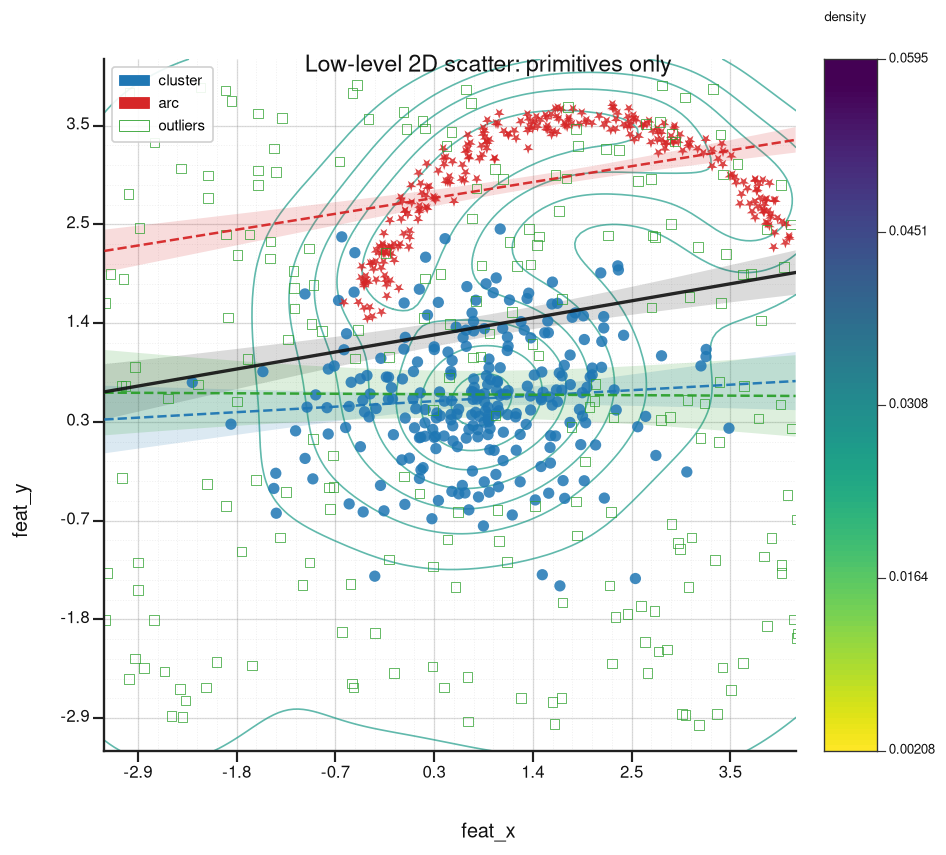

In [38]:
# =====================================================================================
# 11.  DEMO
# =====================================================================================
# Synthetic dataset: three classes with different shapes, overlaps, a deliberate
# "hollow" class, a class drawn with stroke-only markers, and a regime that contains
# a lot of points so the automatic alpha kicks in.

def make_demo_dataset(n_per_class: int = 260, random_state: int = 0) -> "pd.DataFrame":
    """Build a synthetic three-class 2-D dataset.

    Parameters
    ----------
    n_per_class
        Number of points in every class; increase it to see the adaptive alpha.
    random_state
        Seed of the generator.
    """
    import pandas as pd

    rng = np.random.default_rng(random_state)
    frames = []

    # --- class "cluster" : two overlapping Gaussians in a diagonal blob ----------
    frames.append(pd.DataFrame({
        "class": "cluster",
        "feat_x": rng.normal(1.0, 1.0, n_per_class) + rng.normal(0.0, 0.35, n_per_class),
        "feat_y": 0.6 * rng.normal(1.0, 1.0, n_per_class) + rng.normal(0.0, 0.35, n_per_class),
    }))

    # --- class "arc" : a curved banana, so a linear fit is visibly wrong ---------
    t = rng.uniform(0.15, 0.95, size=n_per_class) * np.pi
    frames.append(pd.DataFrame({
        "class": "arc",
        "feat_x": 2.0 + 2.4 * np.cos(t) + rng.normal(0, 0.10, n_per_class),
        "feat_y": 1.2 + 2.4 * np.sin(t) + rng.normal(0, 0.10, n_per_class),
    }))

    # --- class "outliers": uniform noise over the whole plane -------------------
    frames.append(pd.DataFrame({
        "class": "outliers",
        "feat_x": rng.uniform(-4, 5, n_per_class),
        "feat_y": rng.uniform(-3.0, 4.0, n_per_class),
    }))

    return pd.concat(frames, ignore_index=True)


demo_df = make_demo_dataset(n_per_class=260, random_state=7)
print(demo_df.head())
print(demo_df.groupby("class").size())

# ---------------------------------------------------------------------------------
# A fully configured call: per-class colour/alpha/shape, custom grid, tick control,
# both regressions with confidence bands and a KDE density layer.
# ---------------------------------------------------------------------------------
DEMO_CONFIG = {
    "figure": {
        "size": 8.0,
        "plot_fraction": 0.72,
        "anchor": "left",
        "title": "Low-level 2D scatter: primitives only",
        "xlabel": "feat_x",
        "ylabel": "feat_y",
        "legend_loc": "upper left",
    },
    "axes": {"spines": "left_bottom", "linewidth": 1.4, "color": "#202020"},
    "ticks": {
        "major_count": 8,
        "major_start": -5.0,
        "minor_count": 4,
        "major_size": 7.0,
        "minor_size": 3.0,
        "width": 1.3,
        "label_offset": 9.0,
        "collision": {"enabled": True, "strategy": "hide", "gap": 2.5},
    },
    "grid": {
        "show": True,
        "color": "#909090",
        "alpha": 0.30,
        "linestyle": "-",
        "linewidth": 0.8,
        "minor_alpha": 0.15,
        "minor_linestyle": ":",
    },
    "points": {
        "alpha": 0.65,
        "alpha_mode": "auto",          # fades out automatically as N grows
        "alpha_auto": {"max_alpha": 0.85, "min_alpha": 0.05, "pivot": 400.0, "power": 0.45},
        "size": 36.0,                  # marker AREA, points**2
        "edge_width": 0.5,
    },
    "classes": {
        "cluster":  {"color": "#1f77b4", "shape": "circle",       "alpha": 0.60, "size": 40},
        "arc":      {"color": "#d62728", "shape": "star",         "alpha": 0.85, "size": 70},
        "outliers": {"color": "#2ca02c", "shape": "hollow_square", "alpha": 0.45, "size": 26},
    },
    "regression": {
        "show": True, "kind": "linear", "color": "#111111", "linewidth": 2.0,
        "show_ci": True, "ci_alpha": 0.15, "confidence": 0.95, "label": "global trend",
    },
    "class_regression": {
        "show": True, "use_class_color": True, "linestyle": "--", "linewidth": 1.5,
        "show_ci": True, "ci_alpha": 0.16, "label": "{cls} trend",
    },
    "density": {
        "show": True, "mode": "kde", "levels": 8, "line_width": 1.0,
        "line_style": "solid", "line_alpha": 0.7, "line_cmap": "viridis",
        "line_color_index": 0.55, "zorder": 1,
        "colorbar": {"show": True, "label": "density", "ticks": 5},
    },
}

result = scatter2d(
    demo_df,
    x="feat_x",
    y="feat_y",
    class_column="class",
    class_order=["cluster", "arc", "outliers"],
    config=DEMO_CONFIG,
)

print(f"points: {result.n_points}")
print(f"hidden tick labels: {result.hidden_tick_labels}")
print(f"figure is square: {result.fig.get_size_inches()[0] == result.fig.get_size_inches()[1]}")
result.show()

## 12. Gallery

The same data with a different switch flipped each time.

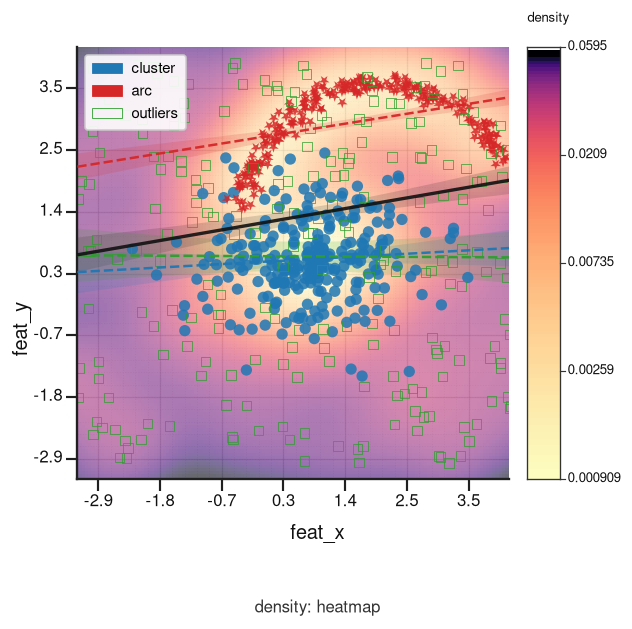

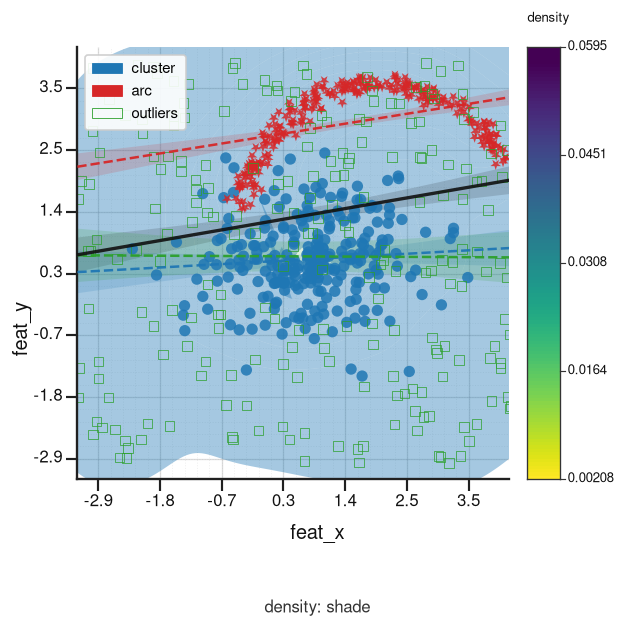

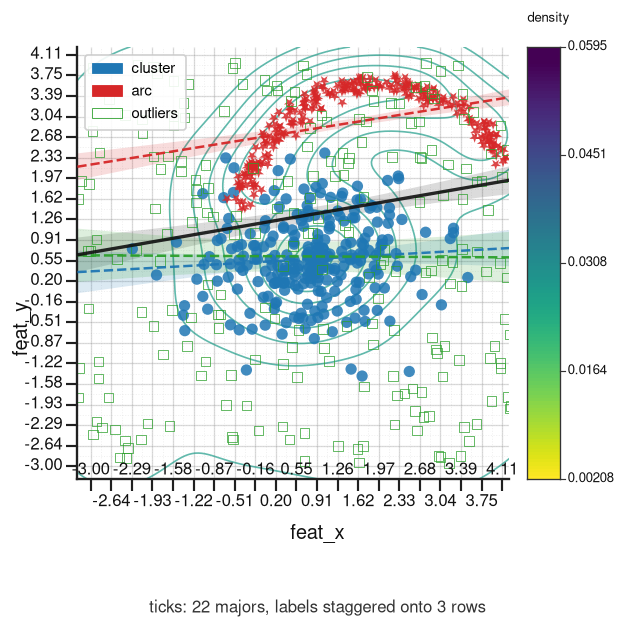

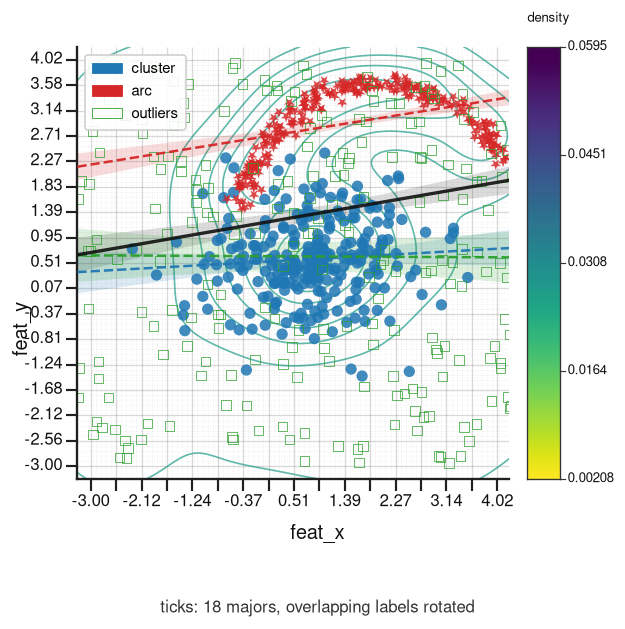

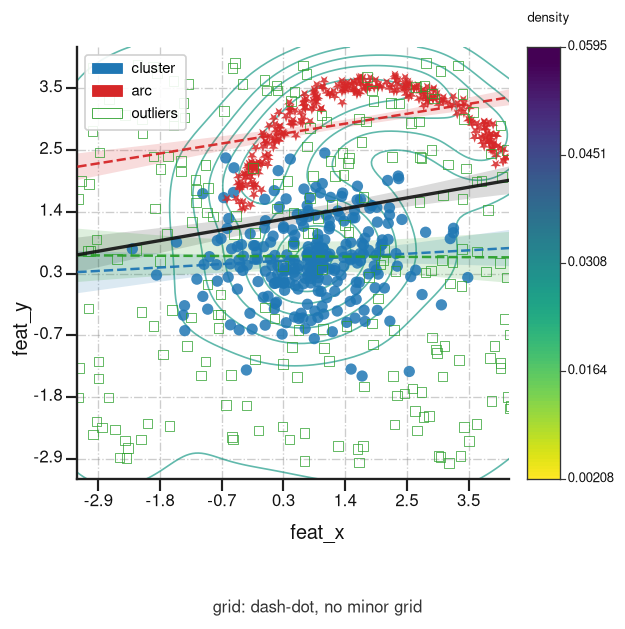

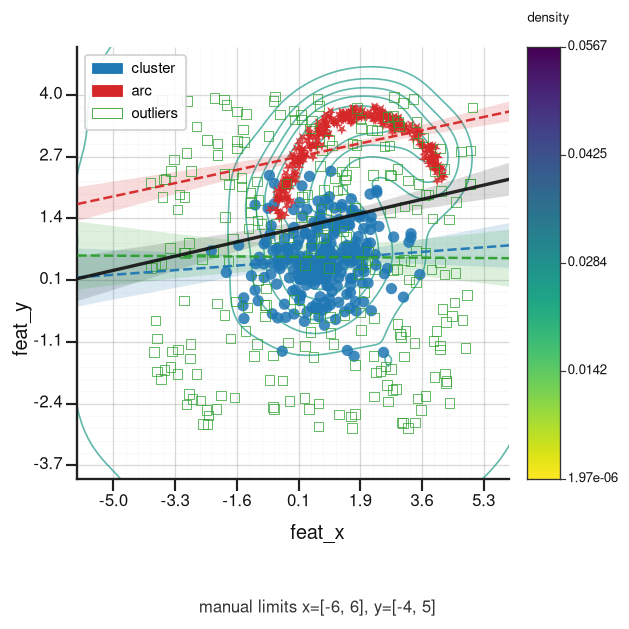

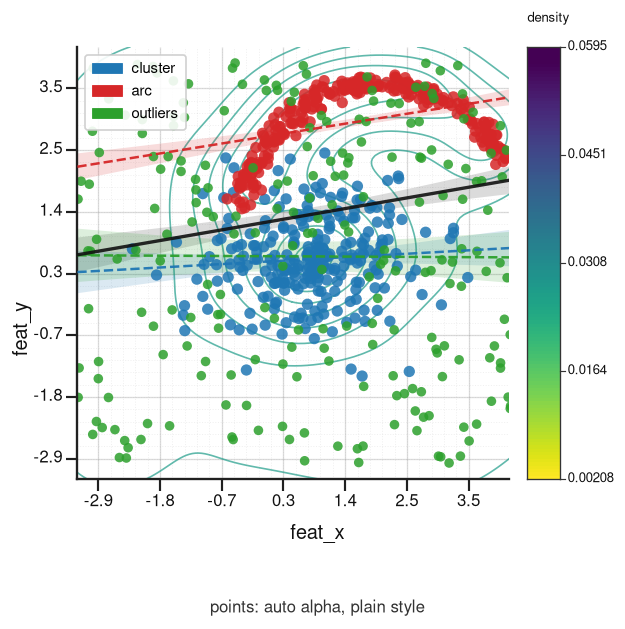

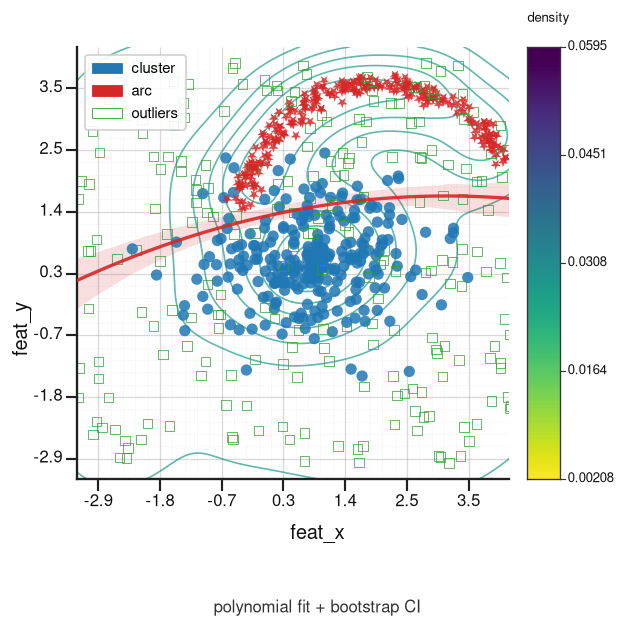

In [39]:
# =====================================================================================
# 12.  GALLERY: the same data rendered with different settings
# =====================================================================================
# A quick visual check that every switch really is independent.

GALLERY: list[tuple[str, dict]] = [
    ("density: heatmap",
     {"density": {"mode": "heatmap", "heatmap": {"bins": 40, "alpha": 0.6}}}),
    ("density: shade",
     {"density": {"mode": "shade", "levels": 9}}),
    ("ticks: 22 majors, labels staggered onto 3 rows",
     {"ticks": {"major_count": 22, "major_start": -3.0, "minor_count": 1,
                "collision": {"strategy": "stagger", "rows": 3, "row_step": 19.0}}}),
    ("ticks: 18 majors, overlapping labels rotated",
     {"ticks": {"major_count": 18, "major_start": -3.0,
                "collision": {"strategy": "rotate",
                              "angles": (0.0, 90.0)}}}),
    ("grid: dash-dot, no minor grid",
     {"grid": {"linestyle": "-.", "alpha": 0.45, "minor": False}}),
    ("manual limits x=[-6, 6], y=[-4, 5]",
     {"axes": {"xlim": (-6.0, 6.0), "ylim": (-4.0, 5.0)}}),
    ("points: auto alpha, plain style",
     {"points": {"alpha_mode": "auto", "size": 26},
      "classes": {"cluster": {"shape": "circle", "color": "#1f77b4"},
                  "arc": {"shape": "circle", "color": "#d62728"},
                  "outliers": {"shape": "circle", "color": "#2ca02c"}}}),
    ("polynomial fit + bootstrap CI",
     {"regression": {"kind": "poly2", "method": "bootstrap", "n_boot": 120,
                     "color": "#d62728"},
      "class_regression": {"show": False}}),
]

# the per-tile captions replace the shared figure title of the main demo
for _title, _patch in GALLERY:
    _patch.setdefault("figure", {})["title"] = None

for _title, _patch in GALLERY:
    _cfg = merge_config(merge_config(DEFAULT_CONFIG, DEMO_CONFIG), _patch)
    _res = scatter2d(
        demo_df, x="feat_x", y="feat_y", class_column="class",
        class_order=["cluster", "arc", "outliers"], config=_cfg, fig_size=5.0,
    )
    _res.fig.text(0.5, 0.02, _title, ha="center", va="bottom",
                  fontsize=10, family=FONT.family, color="#333333")
    plt.show()

## Appendix: previous content of this notebook

The dataset generator that used to be the only cell here (built for a raincloud
plot) is kept unchanged below.